Need to pull and sample 500k points from the 43,000,000 valid pixels in the masked tif

In [2]:
import rasterio
out_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)
with rasterio.open(out_raster) as src:
    print("Band descriptions:")
    for i, desc in enumerate(src.descriptions, start=1):
        print(f"Band {i}: {desc}")

Band descriptions:
Band 1: beta0_B2
Band 2: A1_B2
Band 3: phi1_B2
Band 4: A2_B2
Band 5: phi2_B2
Band 6: A3_B2
Band 7: phi3_B2
Band 8: A4_B2
Band 9: phi4_B2
Band 10: RMSE_B2
Band 11: beta0_B3
Band 12: A1_B3
Band 13: phi1_B3
Band 14: A2_B3
Band 15: phi2_B3
Band 16: A3_B3
Band 17: phi3_B3
Band 18: A4_B3
Band 19: phi4_B3
Band 20: RMSE_B3
Band 21: beta0_B4
Band 22: A1_B4
Band 23: phi1_B4
Band 24: A2_B4
Band 25: phi2_B4
Band 26: A3_B4
Band 27: phi3_B4
Band 28: A4_B4
Band 29: phi4_B4
Band 30: RMSE_B4
Band 31: beta0_B5
Band 32: A1_B5
Band 33: phi1_B5
Band 34: A2_B5
Band 35: phi2_B5
Band 36: A3_B5
Band 37: phi3_B5
Band 38: A4_B5
Band 39: phi4_B5
Band 40: RMSE_B5
Band 41: beta0_B6
Band 42: A1_B6
Band 43: phi1_B6
Band 44: A2_B6
Band 45: phi2_B6
Band 46: A3_B6
Band 47: phi3_B6
Band 48: A4_B6
Band 49: phi4_B6
Band 50: RMSE_B6
Band 51: beta0_B7
Band 52: A1_B7
Band 53: phi1_B7
Band 54: A2_B7
Band 55: phi2_B7
Band 56: A3_B7
Band 57: phi3_B7
Band 58: A4_B7
Band 59: phi4_B7
Band 60: RMSE_B7
Band 61: bet

In [6]:
from __future__ import annotations

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import rasterio
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# =============================================================================
# USER SETTINGS
# =============================================================================

out_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)
out_dir = Path(r"C:\NCA_DATA\cluster_sampling_2025")
out_dir.mkdir(parents=True, exist_ok=True)

sample_n = 500_000
random_seed = 42

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

# clustering range to evaluate
k_values = list(range(20, 43))

# clustering settings
batch_size = 8192
n_init = 20
max_iter = 1000

# silhouette is expensive; compute on a subsample
silhouette_n = 20_000

# final balanced subset target
per_cluster_target = 5_000


# =============================================================================
# EXPLICIT BAND MAP FOR _masked.tif
# =============================================================================
# Band order per raw band:
#   beta0, A1, phi1, A2, phi2, A3, phi3, A4, phi4, RMSE
#
# We only keep beta0 + A1:A4 for raw bands B2:B12/B8A.

FEATURE_MAP = {
    "B2":  {"BETA0": 1,  "AMP1": 2,  "AMP2": 4,  "AMP3": 6,  "AMP4": 8},
    "B3":  {"BETA0": 11, "AMP1": 12, "AMP2": 14, "AMP3": 16, "AMP4": 18},
    "B4":  {"BETA0": 21, "AMP1": 22, "AMP2": 24, "AMP3": 26, "AMP4": 28},
    "B5":  {"BETA0": 31, "AMP1": 32, "AMP2": 34, "AMP3": 36, "AMP4": 38},
    "B6":  {"BETA0": 41, "AMP1": 42, "AMP2": 44, "AMP3": 46, "AMP4": 48},
    "B7":  {"BETA0": 51, "AMP1": 52, "AMP2": 54, "AMP3": 56, "AMP4": 58},
    "B8":  {"BETA0": 61, "AMP1": 62, "AMP2": 64, "AMP3": 66, "AMP4": 68},
    "B8A": {"BETA0": 71, "AMP1": 72, "AMP2": 74, "AMP3": 76, "AMP4": 78},
    "B11": {"BETA0": 81, "AMP1": 82, "AMP2": 84, "AMP3": 86, "AMP4": 88},
    "B12": {"BETA0": 91, "AMP1": 92, "AMP2": 94, "AMP3": 96, "AMP4": 98},
}


# =============================================================================
# HELPERS
# =============================================================================

def validate_feature_map(feature_map: dict[str, dict[str, int]]) -> None:
    needed = ["BETA0", "AMP1", "AMP2", "AMP3", "AMP4"]

    missing = {}
    for band in RAW_BANDS:
        if band not in feature_map:
            missing[band] = needed
            continue
        miss = [k for k in needed if k not in feature_map[band]]
        if miss:
            missing[band] = miss

    if missing:
        raise RuntimeError(f"Feature map missing required entries: {missing}")


def get_selected_band_indices(feature_map: dict[str, dict[str, int]]) -> list[int]:
    selected = []
    for band in RAW_BANDS:
        selected.extend([
            feature_map[band]["BETA0"],
            feature_map[band]["AMP1"],
            feature_map[band]["AMP2"],
            feature_map[band]["AMP3"],
            feature_map[band]["AMP4"],
        ])
    return sorted(set(selected))


def build_selected_band_lookup(
    feature_map: dict[str, dict[str, int]],
    selected_indices_1based: list[int]
) -> dict[str, dict[str, int]]:
    """
    Converts raster 1-based indices into positions within the selected read stack.
    """
    pos_map = {idx: pos for pos, idx in enumerate(selected_indices_1based)}
    lookup = {band: {} for band in RAW_BANDS}

    for band in RAW_BANDS:
        for comp, idx in feature_map[band].items():
            lookup[band][comp] = pos_map[idx]

    return lookup


def get_valid_mask(arr, src) -> np.ndarray:
    """
    Valid pixels are those that:
    - are not masked in any selected band
    - are finite in all selected bands
    - are not equal to src.nodata if nodata is defined numerically
    """
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)

    nodata = src.nodata
    if nodata is not None and np.isfinite(nodata):
        valid &= ~np.any(arr.data == nodata, axis=0)

    return valid


def count_valid_pixels(src, selected_indices_1based: list[int]) -> tuple[list[dict], int]:
    """
    First pass:
      - read only selected bands
      - count valid pixels per block window
      - return metadata for second pass
    """
    window_infos = []
    total_valid = 0

    for _, window in src.block_windows(1):
        arr = src.read(indexes=selected_indices_1based, window=window, masked=True)
        valid = get_valid_mask(arr, src)

        n_valid = int(valid.sum())
        if n_valid > 0:
            window_infos.append({
                "window": window,
                "row_off": int(window.row_off),
                "col_off": int(window.col_off),
                "height": int(window.height),
                "width": int(window.width),
                "n_valid": n_valid
            })
            total_valid += n_valid

    return window_infos, total_valid


def allocate_sample_counts(
    window_infos: list[dict],
    sample_n: int,
    total_valid: int,
    seed: int = 42
) -> np.ndarray:
    """
    Allocate exact sample counts across windows in proportion to valid pixel counts.
    """
    if total_valid < sample_n:
        raise RuntimeError(
            f"Requested sample_n={sample_n:,} but only {total_valid:,} valid pixels exist."
        )

    probs = np.array([w["n_valid"] for w in window_infos], dtype=np.float64)
    probs /= probs.sum()

    rng = np.random.default_rng(seed)
    alloc = rng.multinomial(sample_n, probs)
    return alloc


def extract_features_from_block(
    block: np.ndarray,
    lookup: dict[str, dict[str, int]]
) -> tuple[np.ndarray, np.ndarray]:
    """
    block shape: (selected_bands, rows, cols)

    Returns:
      X_energy : (n_pixels_in_block, 20)
      X_full   : (n_pixels_in_block, 50)
    """
    energy_cols = []
    full_cols = []

    for band in RAW_BANDS:
        beta0 = block[lookup[band]["BETA0"]].reshape(-1)
        a1 = block[lookup[band]["AMP1"]].reshape(-1)
        a2 = block[lookup[band]["AMP2"]].reshape(-1)
        a3 = block[lookup[band]["AMP3"]].reshape(-1)
        a4 = block[lookup[band]["AMP4"]].reshape(-1)

        energy = np.sqrt(a1**2 + a2**2 + a3**2 + a4**2)

        energy_cols.extend([beta0, energy])
        full_cols.extend([beta0, a1, a2, a3, a4])

    X_energy = np.column_stack(energy_cols).astype(np.float32)
    X_full = np.column_stack(full_cols).astype(np.float32)

    return X_energy, X_full


def sample_exact_pixels(
    src,
    window_infos: list[dict],
    alloc: np.ndarray,
    selected_indices_1based: list[int],
    lookup: dict[str, dict[str, int]],
    seed: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Second pass:
      - read windows again
      - sample exact number of valid pixels from each window
      - build energy + full feature matrices
      - store row/col indices
    """
    rng = np.random.default_rng(seed)

    X_energy_parts = []
    X_full_parts = []
    row_parts = []
    col_parts = []

    for w_info, n_take in zip(window_infos, alloc):
        if n_take == 0:
            continue

        window = w_info["window"]
        row_off = w_info["row_off"]
        col_off = w_info["col_off"]

        arr = src.read(indexes=selected_indices_1based, window=window, masked=True)
        valid = get_valid_mask(arr, src)

        valid_rows, valid_cols = np.where(valid)
        n_valid = len(valid_rows)

        if n_take > n_valid:
            raise RuntimeError(
                f"Window allocation requested {n_take} pixels but only {n_valid} valid pixels exist."
            )

        chosen = rng.choice(n_valid, size=n_take, replace=False)
        rr = valid_rows[chosen]
        cc = valid_cols[chosen]

        block = arr.data.astype(np.float32)
        X_energy_block, X_full_block = extract_features_from_block(block, lookup)

        ncols = block.shape[2]
        flat_idx = rr * ncols + cc

        X_energy_parts.append(X_energy_block[flat_idx])
        X_full_parts.append(X_full_block[flat_idx])
        row_parts.append((rr + row_off).astype(np.int32))
        col_parts.append((cc + col_off).astype(np.int32))

    X_energy = np.vstack(X_energy_parts)
    X_full = np.vstack(X_full_parts)
    rows = np.concatenate(row_parts)
    cols = np.concatenate(col_parts)

    return X_energy, X_full, rows, cols


def get_xy_from_rowcol(src, rows: np.ndarray, cols: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    xs, ys = rasterio.transform.xy(src.transform, rows.tolist(), cols.tolist(), offset="center")
    return np.asarray(xs), np.asarray(ys)


def run_k_diagnostics(
    X: np.ndarray,
    name: str,
    k_values: list[int],
    out_dir: Path,
    random_seed: int = 42
) -> tuple[pd.DataFrame, StandardScaler]:
    """
    Standardize X and compute:
      - inertia (WCSS)
      - silhouette on a subsample
      - Calinski-Harabasz (VRC)
    Saves labels + model for each k.
    """
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    joblib.dump(scaler, out_dir / f"{name}_scaler.joblib")

    rng = np.random.default_rng(random_seed)
    sil_idx = rng.choice(Xz.shape[0], size=min(silhouette_n, Xz.shape[0]), replace=False)

    results = []

    for k in k_values:
        model = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_seed,
            batch_size=batch_size,
            n_init=n_init,
            max_iter=max_iter,
            compute_labels=True
        )

        labels = model.fit_predict(Xz)

        sil = silhouette_score(Xz[sil_idx], labels[sil_idx])
        ch = calinski_harabasz_score(Xz, labels)
        inertia = float(model.inertia_)

        np.save(out_dir / f"{name}_labels_k{k}.npy", labels)
        joblib.dump(model, out_dir / f"{name}_kmeans_k{k}.joblib")

        cluster_sizes = pd.Series(labels).value_counts().sort_index()
        cluster_sizes.to_csv(out_dir / f"{name}_cluster_sizes_k{k}.csv", header=["n"])

        results.append({
            "dataset": name,
            "k": k,
            "inertia_wcss": inertia,
            "silhouette": sil,
            "variance_ratio_criterion": ch,
            "min_cluster_size": int(cluster_sizes.min()),
            "max_cluster_size": int(cluster_sizes.max())
        })

        print(
            f"[{name}] k={k:2d} | "
            f"WCSS={inertia:,.2f} | "
            f"silhouette={sil:.4f} | "
            f"VRC={ch:,.2f}"
        )

    results_df = pd.DataFrame(results)
    results_df.to_csv(out_dir / f"{name}_k_diagnostics.csv", index=False)
    return results_df, scaler


def subset_per_cluster(
    rows: np.ndarray,
    cols: np.ndarray,
    xs: np.ndarray,
    ys: np.ndarray,
    labels: np.ndarray,
    per_cluster_target: int,
    seed: int = 42
) -> pd.DataFrame:
    """
    Subsample to up to per_cluster_target points per cluster.
    """
    rng = np.random.default_rng(seed)
    parts = []

    for cluster_id in np.sort(np.unique(labels)):
        idx = np.where(labels == cluster_id)[0]
        n_take = min(per_cluster_target, len(idx))
        chosen = rng.choice(idx, size=n_take, replace=False)

        parts.append(pd.DataFrame({
            "point_id": [f"pt_{cluster_id}_{i}" for i in range(n_take)],
            "cluster": cluster_id,
            "row": rows[chosen],
            "col": cols[chosen],
            "x": xs[chosen],
            "y": ys[chosen]
        }))

    return pd.concat(parts, ignore_index=True)


# =============================================================================
# MAIN
# =============================================================================

def main():
    validate_feature_map(FEATURE_MAP)

    selected_indices_1based = get_selected_band_indices(FEATURE_MAP)
    lookup = build_selected_band_lookup(FEATURE_MAP, selected_indices_1based)

    print("Using explicit band map for raw bands only.")
    print("Selected raster bands needed for feature construction:")
    print(selected_indices_1based)

    with rasterio.open(out_raster) as src:
        print("Raster:", out_raster)
        print("CRS:", src.crs)
        print("Shape:", (src.height, src.width))
        print("Count:", src.count)
        print("Nodata:", src.nodata)
        print("Mask flags band 1:", src.mask_flag_enums[0])

        print("First pass: counting valid pixels by window...")
        window_infos, total_valid = count_valid_pixels(src, selected_indices_1based)
        print(f"Total valid pixels across selected features: {total_valid:,}")

        alloc = allocate_sample_counts(window_infos, sample_n, total_valid, seed=random_seed)

        print("Second pass: extracting exact random sample and building feature matrices...")
        X_energy, X_full, rows, cols = sample_exact_pixels(
            src=src,
            window_infos=window_infos,
            alloc=alloc,
            selected_indices_1based=selected_indices_1based,
            lookup=lookup,
            seed=random_seed
        )

        xs, ys = get_xy_from_rowcol(src, rows, cols)

        print(f"Sampled pixels: {len(rows):,}")
        print(f"Energy feature matrix shape: {X_energy.shape}")
        print(f"Full feature matrix shape:   {X_full.shape}")

        np.save(out_dir / "X_energy_500k.npy", X_energy)
        np.save(out_dir / "X_full_500k.npy", X_full)
        np.save(out_dir / "rows_500k.npy", rows)
        np.save(out_dir / "cols_500k.npy", cols)
        np.save(out_dir / "xs_500k.npy", xs)
        np.save(out_dir / "ys_500k.npy", ys)

    print("\nRunning clustering diagnostics: Parseval-energy version...")
    energy_diag, _ = run_k_diagnostics(
        X=X_energy,
        name="energy",
        k_values=k_values,
        out_dir=out_dir,
        random_seed=random_seed
    )

    print("\nRunning clustering diagnostics: full 50-feature version...")
    full_diag, _ = run_k_diagnostics(
        X=X_full,
        name="full50",
        k_values=k_values,
        out_dir=out_dir,
        random_seed=random_seed
    )

    combined_diag = pd.concat([energy_diag, full_diag], ignore_index=True)
    combined_diag.to_csv(out_dir / "combined_k_diagnostics.csv", index=False)

    print("\nDone.")
    print("Next step:")
    print("1. Review energy_k_diagnostics.csv and full50_k_diagnostics.csv")
    print("2. Choose optimal k for each representation")
    print("3. Run the subset block below to retain up to 5000 per cluster")


if __name__ == "__main__":
    main()

Using explicit band map for raw bands only.
Selected raster bands needed for feature construction:
[1, 2, 4, 6, 8, 11, 12, 14, 16, 18, 21, 22, 24, 26, 28, 31, 32, 34, 36, 38, 41, 42, 44, 46, 48, 51, 52, 54, 56, 58, 61, 62, 64, 66, 68, 71, 72, 74, 76, 78, 81, 82, 84, 86, 88, 91, 92, 94, 96, 98]
Raster: C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif
CRS: EPSG:26911
Shape: (7857, 10435)
Count: 151
Nodata: -32768.0
Mask flags band 1: [<MaskFlags.nodata: 8>]
First pass: counting valid pixels by window...
Total valid pixels across selected features: 43,510,891
Second pass: extracting exact random sample and building feature matrices...
Sampled pixels: 500,000
Energy feature matrix shape: (500000, 20)
Full feature matrix shape:   (500000, 50)

Running clustering diagnostics: Parseval-energy version...
[energy] k=20 | WCSS=9,969,008.00 | silhouette=0.1217 | VRC=675.50
[energy] k=21 | WCSS=9,993,588.00 | silhouette=0.1332 | VRC=237.40
[energy] k=22 | WCSS=9,993,168.00

In [ ]:
#QA/QC for 500k block

from pathlib import Path

import numpy as np
import pandas as pd


# =============================================================================
# USER SETTINGS
# =============================================================================

out_dir = Path(r"C:\NCA_DATA\cluster_sampling_2025")

energy_file = out_dir / "X_energy_500k.npy"
full_file   = out_dir / "X_full_500k.npy"
rows_file   = out_dir / "rows_500k.npy"
cols_file   = out_dir / "cols_500k.npy"
xs_file     = out_dir / "xs_500k.npy"
ys_file     = out_dir / "ys_500k.npy"

random_seed = 42
preview_n = 10
suspect_abs_threshold = 1e3  # catches absurd values if something leaked through


# =============================================================================
# HELPERS
# =============================================================================

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

energy_feature_names = []
for b in RAW_BANDS:
    energy_feature_names.extend([f"beta0_{b}", f"energy_{b}"])

full_feature_names = []
for b in RAW_BANDS:
    full_feature_names.extend([
        f"beta0_{b}",
        f"A1_{b}",
        f"A2_{b}",
        f"A3_{b}",
        f"A4_{b}",
    ])


def summarize_matrix(X: np.ndarray, feature_names: list[str], name: str) -> pd.DataFrame:
    """
    Per-column summary statistics.
    """
    if X.shape[1] != len(feature_names):
        raise RuntimeError(
            f"{name}: expected {len(feature_names)} feature names but matrix has {X.shape[1]} columns."
        )

    finite_mask = np.isfinite(X)

    summary = pd.DataFrame({
        "feature": feature_names,
        "dtype": [str(X.dtype)] * X.shape[1],
        "n_rows": [X.shape[0]] * X.shape[1],
        "n_finite": finite_mask.sum(axis=0),
        "n_nan": np.isnan(X).sum(axis=0),
        "n_posinf": np.isposinf(X).sum(axis=0),
        "n_neginf": np.isneginf(X).sum(axis=0),
        "min": np.nanmin(X, axis=0),
        "p01": np.nanpercentile(X, 1, axis=0),
        "p05": np.nanpercentile(X, 5, axis=0),
        "mean": np.nanmean(X, axis=0),
        "std": np.nanstd(X, axis=0),
        "p50": np.nanpercentile(X, 50, axis=0),
        "p95": np.nanpercentile(X, 95, axis=0),
        "p99": np.nanpercentile(X, 99, axis=0),
        "max": np.nanmax(X, axis=0),
        "n_abs_gt_threshold": (np.abs(X) > suspect_abs_threshold).sum(axis=0),
        "n_eq_nodata_-32768": (X == -32768).sum(axis=0),
        "n_eq_zero": (X == 0).sum(axis=0),
        "n_negative": (X < 0).sum(axis=0),
    })

    summary["pct_nan"] = 100 * summary["n_nan"] / summary["n_rows"]
    summary["pct_eq_nodata_-32768"] = 100 * summary["n_eq_nodata_-32768"] / summary["n_rows"]
    summary["pct_zero"] = 100 * summary["n_eq_zero"] / summary["n_rows"]
    summary["pct_negative"] = 100 * summary["n_negative"] / summary["n_rows"]

    return summary


def preview_rows(X: np.ndarray, feature_names: list[str], name: str, n: int = 10, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=min(n, X.shape[0]), replace=False)
    df = pd.DataFrame(X[idx], columns=feature_names)
    df.insert(0, "row_index_in_matrix", idx)
    df.insert(0, "dataset", name)
    return df


def summarize_vector(v: np.ndarray, name: str) -> pd.Series:
    return pd.Series({
        "name": name,
        "dtype": str(v.dtype),
        "n": len(v),
        "n_nan": np.isnan(v).sum() if np.issubdtype(v.dtype, np.floating) else 0,
        "min": np.min(v),
        "max": np.max(v),
        "mean": np.mean(v),
        "std": np.std(v),
        "n_unique": len(np.unique(v[:min(len(v), 200000)]))  # capped for speed
    })


def compare_energy_vs_full(
    X_energy: np.ndarray,
    X_full: np.ndarray
) -> pd.DataFrame:
    """
    Check that energy columns equal sqrt(A1^2 + A2^2 + A3^2 + A4^2)
    from the full matrix.
    """
    rows = []

    # full matrix layout per band: beta0, A1, A2, A3, A4
    # energy layout per band: beta0, energy
    for i, band in enumerate(RAW_BANDS):
        e_beta_col = 2 * i
        e_energy_col = 2 * i + 1

        f_beta_col = 5 * i
        f_a1_col = 5 * i + 1
        f_a2_col = 5 * i + 2
        f_a3_col = 5 * i + 3
        f_a4_col = 5 * i + 4

        beta_diff = np.abs(X_energy[:, e_beta_col] - X_full[:, f_beta_col])
        rebuilt_energy = np.sqrt(
            X_full[:, f_a1_col] ** 2 +
            X_full[:, f_a2_col] ** 2 +
            X_full[:, f_a3_col] ** 2 +
            X_full[:, f_a4_col] ** 2
        )
        energy_diff = np.abs(X_energy[:, e_energy_col] - rebuilt_energy)

        rows.append({
            "band": band,
            "beta_max_abs_diff": beta_diff.max(),
            "beta_mean_abs_diff": beta_diff.mean(),
            "energy_max_abs_diff": energy_diff.max(),
            "energy_mean_abs_diff": energy_diff.mean(),
        })

    return pd.DataFrame(rows)


# =============================================================================
# LOAD ARRAYS
# =============================================================================

print("Loading .npy files...")

X_energy = np.load(energy_file)
X_full   = np.load(full_file)
rows     = np.load(rows_file)
cols     = np.load(cols_file)
xs       = np.load(xs_file)
ys       = np.load(ys_file)

print("Loaded:")
print("  X_energy:", X_energy.shape, X_energy.dtype)
print("  X_full:  ", X_full.shape, X_full.dtype)
print("  rows:    ", rows.shape, rows.dtype)
print("  cols:    ", cols.shape, cols.dtype)
print("  xs:      ", xs.shape, xs.dtype)
print("  ys:      ", ys.shape, ys.dtype)


# =============================================================================
# BASIC STRUCTURE CHECKS
# =============================================================================

print("\nRunning basic structure checks...")

assert X_energy.shape == (500000, 20), f"Unexpected X_energy shape: {X_energy.shape}"
assert X_full.shape == (500000, 50), f"Unexpected X_full shape: {X_full.shape}"

n = X_energy.shape[0]
assert X_full.shape[0] == n
assert len(rows) == n
assert len(cols) == n
assert len(xs) == n
assert len(ys) == n

assert np.all(np.isfinite(rows))
assert np.all(np.isfinite(cols))
assert np.all(np.isfinite(xs))
assert np.all(np.isfinite(ys))

print("Basic shape checks passed.")


# =============================================================================
# DUPLICATE / INDEX / COORDINATE CHECKS
# =============================================================================

print("\nChecking index uniqueness and coordinate sanity...")

rc_df = pd.DataFrame({"row": rows, "col": cols})
n_duplicates = rc_df.duplicated().sum()

print(f"Duplicate sampled row/col pairs: {n_duplicates:,}")

coord_summary = pd.DataFrame([
    summarize_vector(rows, "rows"),
    summarize_vector(cols, "cols"),
    summarize_vector(xs, "xs"),
    summarize_vector(ys, "ys"),
])

coord_summary.to_csv(out_dir / "npy_coordinate_summaries.csv", index=False)
print(coord_summary)


# =============================================================================
# FEATURE MATRIX SUMMARIES
# =============================================================================

print("\nSummarizing energy matrix...")
energy_summary = summarize_matrix(X_energy, energy_feature_names, "energy")
energy_summary.to_csv(out_dir / "X_energy_500k_summary.csv", index=False)

print("\nSummarizing full50 matrix...")
full_summary = summarize_matrix(X_full, full_feature_names, "full50")
full_summary.to_csv(out_dir / "X_full_500k_summary.csv", index=False)

print("\nTop suspicious energy features (sorted by nodata leakage, NaNs, absurd values):")
print(
    energy_summary.sort_values(
        ["n_eq_nodata_-32768", "n_nan", "n_abs_gt_threshold"],
        ascending=False
    ).head(10)[[
        "feature", "n_eq_nodata_-32768", "n_nan", "n_abs_gt_threshold", "min", "max", "std"
    ]]
)

print("\nTop suspicious full50 features (sorted by nodata leakage, NaNs, absurd values):")
print(
    full_summary.sort_values(
        ["n_eq_nodata_-32768", "n_nan", "n_abs_gt_threshold"],
        ascending=False
    ).head(10)[[
        "feature", "n_eq_nodata_-32768", "n_nan", "n_abs_gt_threshold", "min", "max", "std"
    ]]
)


# =============================================================================
# ENERGY VS FULL CONSISTENCY CHECK
# =============================================================================

print("\nChecking consistency between X_energy and X_full...")
consistency_df = compare_energy_vs_full(X_energy, X_full)
consistency_df.to_csv(out_dir / "energy_vs_full_consistency.csv", index=False)
print(consistency_df)

tol = 1e-5
if (consistency_df["beta_max_abs_diff"] > tol).any():
    print("\nWARNING: beta columns differ between energy and full matrices.")
if (consistency_df["energy_max_abs_diff"] > tol).any():
    print("\nWARNING: energy columns do not match sqrt(A1^2 + A2^2 + A3^2 + A4^2).")
else:
    print("\nEnergy/full consistency checks look good.")


# =============================================================================
# PREVIEWS
# =============================================================================

print("\nWriting random row previews...")
energy_preview = preview_rows(X_energy, energy_feature_names, "energy", n=preview_n, seed=random_seed)
full_preview   = preview_rows(X_full, full_feature_names, "full50", n=preview_n, seed=random_seed)

energy_preview.to_csv(out_dir / "X_energy_500k_preview.csv", index=False)
full_preview.to_csv(out_dir / "X_full_500k_preview.csv", index=False)

print("\nEnergy preview:")
print(energy_preview)

print("\nFull50 preview:")
print(full_preview)


# =============================================================================
# GLOBAL SANITY FLAGS
# =============================================================================

print("\nGlobal sanity checks...")

def matrix_flags(summary_df: pd.DataFrame, name: str) -> None:
    any_nodata = (summary_df["n_eq_nodata_-32768"] > 0).any()
    any_nan = (summary_df["n_nan"] > 0).any()
    any_inf = ((summary_df["n_posinf"] > 0) | (summary_df["n_neginf"] > 0)).any()
    low_variance = (summary_df["std"] < 1e-8).sum()

    print(f"\n{name}:")
    print(f"  Any -32768 leakage? {'YES' if any_nodata else 'NO'}")
    print(f"  Any NaNs? {'YES' if any_nan else 'NO'}")
    print(f"  Any Infs? {'YES' if any_inf else 'NO'}")
    print(f"  Near-zero variance columns (<1e-8 std): {low_variance}")

matrix_flags(energy_summary, "X_energy")
matrix_flags(full_summary, "X_full")

print("\nDone.")
print("Files written:")
print("  X_energy_500k_summary.csv")
print("  X_full_500k_summary.csv")
print("  energy_vs_full_consistency.csv")
print("  X_energy_500k_preview.csv")
print("  X_full_500k_preview.csv")
print("  npy_coordinate_summaries.csv")

Loading .npy files...
Loaded:
  X_energy: (500000, 20) float32
  X_full:   (500000, 50) float32
  rows:     (500000,) int32
  cols:     (500000,) int32
  xs:       (500000,) float64
  ys:       (500000,) float64

Running basic structure checks...
Basic shape checks passed.

Checking index uniqueness and coordinate sanity...
Duplicate sampled row/col pairs: 0
   name    dtype       n  n_nan        min        max          mean  \
0  rows    int32  500000      0        0.0     7856.0  3.900439e+03   
1  cols    int32  500000      0        0.0    10433.0  5.037461e+03   
2    xs  float64  500000      0   527745.0   632075.0  5.781196e+05   
3    ys  float64  500000      0  4736845.0  4815405.0  4.776401e+06   

            std  n_unique  
0   1779.641891      3583  
1   2689.961018      8735  
2  26899.610181      8735  
3  17796.418907      3583  

Summarizing energy matrix...

Summarizing full50 matrix...

Top suspicious energy features (sorted by nodata leakage, NaNs, absurd values):
  

In [11]:
from __future__ import annotations

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import rasterio
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# =============================================================================
# USER SETTINGS
# =============================================================================

out_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)
out_dir = Path(r"C:\NCA_DATA\cluster_v2")
out_dir.mkdir(parents=True, exist_ok=True)

sample_n = 1_000_000
random_seed = 42

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

k_values = list(range(15, 31))

batch_size = 8192
n_init = 20
max_iter = 1000

# silhouette settings: 5 independent subsamples of 40k each
silhouette_repeats = 5
silhouette_n = 40_000

per_cluster_target = 5_000


# =============================================================================
# EXPLICIT BAND MAP
# =============================================================================

FEATURE_MAP = {
    "B2":  {"BETA0": 1,  "AMP1": 2,  "AMP2": 4,  "AMP3": 6,  "AMP4": 8},
    "B3":  {"BETA0": 11, "AMP1": 12, "AMP2": 14, "AMP3": 16, "AMP4": 18},
    "B4":  {"BETA0": 21, "AMP1": 22, "AMP2": 24, "AMP3": 26, "AMP4": 28},
    "B5":  {"BETA0": 31, "AMP1": 32, "AMP2": 34, "AMP3": 36, "AMP4": 38},
    "B6":  {"BETA0": 41, "AMP1": 42, "AMP2": 44, "AMP3": 46, "AMP4": 48},
    "B7":  {"BETA0": 51, "AMP1": 52, "AMP2": 54, "AMP3": 56, "AMP4": 58},
    "B8":  {"BETA0": 61, "AMP1": 62, "AMP2": 64, "AMP3": 66, "AMP4": 68},
    "B8A": {"BETA0": 71, "AMP1": 72, "AMP2": 74, "AMP3": 76, "AMP4": 78},
    "B11": {"BETA0": 81, "AMP1": 82, "AMP2": 84, "AMP3": 86, "AMP4": 88},
    "B12": {"BETA0": 91, "AMP1": 92, "AMP2": 94, "AMP3": 96, "AMP4": 98},
}


# =============================================================================
# HELPERS
# =============================================================================

def validate_feature_map(feature_map: dict[str, dict[str, int]]) -> None:
    needed = ["BETA0", "AMP1", "AMP2", "AMP3", "AMP4"]
    missing = {}
    for band in RAW_BANDS:
        if band not in feature_map:
            missing[band] = needed
            continue
        miss = [k for k in needed if k not in feature_map[band]]
        if miss:
            missing[band] = miss
    if missing:
        raise RuntimeError(f"Feature map missing required entries: {missing}")


def get_selected_band_indices(feature_map: dict[str, dict[str, int]]) -> list[int]:
    selected = []
    for band in RAW_BANDS:
        selected.extend([
            feature_map[band]["BETA0"],
            feature_map[band]["AMP1"],
            feature_map[band]["AMP2"],
            feature_map[band]["AMP3"],
            feature_map[band]["AMP4"],
        ])
    return sorted(set(selected))


def build_selected_band_lookup(
    feature_map: dict[str, dict[str, int]],
    selected_indices_1based: list[int]
) -> dict[str, dict[str, int]]:
    pos_map = {idx: pos for pos, idx in enumerate(selected_indices_1based)}
    lookup = {band: {} for band in RAW_BANDS}
    for band in RAW_BANDS:
        for comp, idx in feature_map[band].items():
            lookup[band][comp] = pos_map[idx]
    return lookup


def get_valid_mask(arr, src) -> np.ndarray:
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)
    nodata = src.nodata
    if nodata is not None and np.isfinite(nodata):
        valid &= ~np.any(arr.data == nodata, axis=0)
    return valid


def count_valid_pixels(src, selected_indices_1based: list[int]) -> tuple[list[dict], int]:
    window_infos = []
    total_valid = 0
    for _, window in src.block_windows(1):
        arr = src.read(indexes=selected_indices_1based, window=window, masked=True)
        valid = get_valid_mask(arr, src)
        n_valid = int(valid.sum())
        if n_valid > 0:
            window_infos.append({
                "window": window,
                "row_off": int(window.row_off),
                "col_off": int(window.col_off),
                "height": int(window.height),
                "width": int(window.width),
                "n_valid": n_valid
            })
            total_valid += n_valid
    return window_infos, total_valid


def allocate_sample_counts(
    window_infos: list[dict],
    sample_n: int,
    total_valid: int,
    seed: int = 42
) -> np.ndarray:
    if total_valid < sample_n:
        raise RuntimeError(
            f"Requested sample_n={sample_n:,} but only {total_valid:,} valid pixels exist."
        )
    probs = np.array([w["n_valid"] for w in window_infos], dtype=np.float64)
    probs /= probs.sum()
    rng = np.random.default_rng(seed)
    alloc = rng.multinomial(sample_n, probs)
    return alloc


def extract_features_from_block(
    block: np.ndarray,
    lookup: dict[str, dict[str, int]]
) -> tuple[np.ndarray, np.ndarray]:
    energy_cols = []
    full_cols = []

    for band in RAW_BANDS:
        beta0 = block[lookup[band]["BETA0"]].reshape(-1)
        a1 = block[lookup[band]["AMP1"]].reshape(-1)
        a2 = block[lookup[band]["AMP2"]].reshape(-1)
        a3 = block[lookup[band]["AMP3"]].reshape(-1)
        a4 = block[lookup[band]["AMP4"]].reshape(-1)

        energy = np.sqrt(a1**2 + a2**2 + a3**2 + a4**2)

        energy_cols.extend([beta0, energy])
        full_cols.extend([beta0, a1, a2, a3, a4])

    X_energy = np.column_stack(energy_cols).astype(np.float32)
    X_full = np.column_stack(full_cols).astype(np.float32)
    return X_energy, X_full


def sample_exact_pixels(
    src,
    window_infos: list[dict],
    alloc: np.ndarray,
    selected_indices_1based: list[int],
    lookup: dict[str, dict[str, int]],
    seed: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)

    X_energy_parts = []
    X_full_parts = []
    row_parts = []
    col_parts = []

    for w_info, n_take in zip(window_infos, alloc):
        if n_take == 0:
            continue

        window = w_info["window"]
        row_off = w_info["row_off"]
        col_off = w_info["col_off"]

        arr = src.read(indexes=selected_indices_1based, window=window, masked=True)
        valid = get_valid_mask(arr, src)

        valid_rows, valid_cols = np.where(valid)
        n_valid = len(valid_rows)

        if n_take > n_valid:
            raise RuntimeError(
                f"Window allocation requested {n_take} pixels but only {n_valid} valid pixels exist."
            )

        chosen = rng.choice(n_valid, size=n_take, replace=False)
        rr = valid_rows[chosen]
        cc = valid_cols[chosen]

        block = arr.data.astype(np.float32)
        X_energy_block, X_full_block = extract_features_from_block(block, lookup)

        ncols = block.shape[2]
        flat_idx = rr * ncols + cc

        X_energy_parts.append(X_energy_block[flat_idx])
        X_full_parts.append(X_full_block[flat_idx])
        row_parts.append((rr + row_off).astype(np.int32))
        col_parts.append((cc + col_off).astype(np.int32))

    X_energy = np.vstack(X_energy_parts)
    X_full = np.vstack(X_full_parts)
    rows = np.concatenate(row_parts)
    cols = np.concatenate(col_parts)

    return X_energy, X_full, rows, cols


def get_xy_from_rowcol(src, rows: np.ndarray, cols: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    xs, ys = rasterio.transform.xy(src.transform, rows.tolist(), cols.tolist(), offset="center")
    return np.asarray(xs), np.asarray(ys)


def compute_repeated_silhouette(
    Xz: np.ndarray,
    labels: np.ndarray,
    n_subsample: int,
    n_repeats: int,
    seed: int
) -> tuple[float, float, list[float]]:
    rng = np.random.default_rng(seed)
    sil_values = []

    for rep in range(n_repeats):
        idx = rng.choice(Xz.shape[0], size=min(n_subsample, Xz.shape[0]), replace=False)
        sil = silhouette_score(Xz[idx], labels[idx])
        sil_values.append(float(sil))

    sil_mean = float(np.mean(sil_values))
    sil_sd = float(np.std(sil_values))
    return sil_mean, sil_sd, sil_values


def run_k_diagnostics(
    X: np.ndarray,
    name: str,
    k_values: list[int],
    out_dir: Path,
    random_seed: int = 42
) -> tuple[pd.DataFrame, StandardScaler]:
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)
    joblib.dump(scaler, out_dir / f"{name}_scaler.joblib")

    results = []

    for k in k_values:
        model = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_seed,
            batch_size=batch_size,
            n_init=n_init,
            max_iter=max_iter,
            compute_labels=True
        )

        labels = model.fit_predict(Xz)

        sil_mean, sil_sd, sil_values = compute_repeated_silhouette(
            Xz=Xz,
            labels=labels,
            n_subsample=silhouette_n,
            n_repeats=silhouette_repeats,
            seed=random_seed + 100 * k
        )

        ch = calinski_harabasz_score(Xz, labels)
        inertia = float(model.inertia_)

        np.save(out_dir / f"{name}_labels_k{k}.npy", labels)
        joblib.dump(model, out_dir / f"{name}_kmeans_k{k}.joblib")

        cluster_sizes = pd.Series(labels).value_counts().sort_index()
        cluster_sizes.to_csv(out_dir / f"{name}_cluster_sizes_k{k}.csv", header=["n"])

        pd.DataFrame({
            "k": [k] * silhouette_repeats,
            "silhouette_repeat": list(range(1, silhouette_repeats + 1)),
            "silhouette_value": sil_values
        }).to_csv(out_dir / f"{name}_silhouette_repeats_k{k}.csv", index=False)

        results.append({
            "dataset": name,
            "k": k,
            "inertia_wcss": inertia,
            "silhouette_mean": sil_mean,
            "silhouette_sd": sil_sd,
            "variance_ratio_criterion": ch,
            "min_cluster_size": int(cluster_sizes.min()),
            "max_cluster_size": int(cluster_sizes.max())
        })

        print(
            f"[{name}] k={k:2d} | "
            f"WCSS={inertia:,.2f} | "
            f"sil_mean={sil_mean:.4f} | "
            f"sil_sd={sil_sd:.4f} | "
            f"VRC={ch:,.2f}"
        )

    results_df = pd.DataFrame(results)
    results_df.to_csv(out_dir / f"{name}_k_diagnostics.csv", index=False)
    return results_df, scaler


# =============================================================================
# MAIN
# =============================================================================

def main():
    validate_feature_map(FEATURE_MAP)

    selected_indices_1based = get_selected_band_indices(FEATURE_MAP)
    lookup = build_selected_band_lookup(FEATURE_MAP, selected_indices_1based)

    print("Using explicit band map for raw bands only.")
    print("Selected raster bands needed for feature construction:")
    print(selected_indices_1based)

    with rasterio.open(out_raster) as src:
        print("Raster:", out_raster)
        print("CRS:", src.crs)
        print("Shape:", (src.height, src.width))
        print("Count:", src.count)
        print("Nodata:", src.nodata)
        print("Mask flags band 1:", src.mask_flag_enums[0])

        print("First pass: counting valid pixels by window...")
        window_infos, total_valid = count_valid_pixels(src, selected_indices_1based)
        print(f"Total valid pixels across selected features: {total_valid:,}")

        alloc = allocate_sample_counts(window_infos, sample_n, total_valid, seed=random_seed)

        print("Second pass: extracting exact random sample and building feature matrices...")
        X_energy, X_full, rows, cols = sample_exact_pixels(
            src=src,
            window_infos=window_infos,
            alloc=alloc,
            selected_indices_1based=selected_indices_1based,
            lookup=lookup,
            seed=random_seed
        )

        xs, ys = get_xy_from_rowcol(src, rows, cols)

        print(f"Sampled pixels: {len(rows):,}")
        print(f"Energy feature matrix shape: {X_energy.shape}")
        print(f"Full feature matrix shape:   {X_full.shape}")

        np.save(out_dir / "X_energy_1M.npy", X_energy)
        np.save(out_dir / "X_full_1M.npy", X_full)
        np.save(out_dir / "rows_1M.npy", rows)
        np.save(out_dir / "cols_1M.npy", cols)
        np.save(out_dir / "xs_1M.npy", xs)
        np.save(out_dir / "ys_1M.npy", ys)

    print("\nRunning clustering diagnostics: Parseval-energy version...")
    energy_diag, _ = run_k_diagnostics(
        X=X_energy,
        name="energy",
        k_values=k_values,
        out_dir=out_dir,
        random_seed=random_seed
    )

    print("\nRunning clustering diagnostics: full 50-feature version...")
    full_diag, _ = run_k_diagnostics(
        X=X_full,
        name="full50",
        k_values=k_values,
        out_dir=out_dir,
        random_seed=random_seed
    )

    combined_diag = pd.concat([energy_diag, full_diag], ignore_index=True)
    combined_diag.to_csv(out_dir / "combined_k_diagnostics.csv", index=False)

    print("\nDone.")
    print("Files written to:", out_dir)


if __name__ == "__main__":
    main()

Using explicit band map for raw bands only.
Selected raster bands needed for feature construction:
[1, 2, 4, 6, 8, 11, 12, 14, 16, 18, 21, 22, 24, 26, 28, 31, 32, 34, 36, 38, 41, 42, 44, 46, 48, 51, 52, 54, 56, 58, 61, 62, 64, 66, 68, 71, 72, 74, 76, 78, 81, 82, 84, 86, 88, 91, 92, 94, 96, 98]
Raster: C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif
CRS: EPSG:26911
Shape: (7857, 10435)
Count: 151
Nodata: -32768.0
Mask flags band 1: [<MaskFlags.nodata: 8>]
First pass: counting valid pixels by window...
Total valid pixels across selected features: 43,510,891
Second pass: extracting exact random sample and building feature matrices...
Sampled pixels: 1,000,000
Energy feature matrix shape: (1000000, 20)
Full feature matrix shape:   (1000000, 50)

Running clustering diagnostics: Parseval-energy version...
[energy] k=15 | WCSS=19,986,964.00 | sil_mean=0.1017 | sil_sd=0.0034 | VRC=1,452.93
[energy] k=16 | WCSS=19,987,466.00 | sil_mean=0.0550 | sil_sd=0.0066 | VRC=1,33

In [14]:
#cluster_v3
from __future__ import annotations

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import rasterio
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# =============================================================================
# USER SETTINGS
# =============================================================================

out_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)
out_dir = Path(r"C:\NCA_DATA\cluster_v3")
out_dir.mkdir(parents=True, exist_ok=True)

sample_n = 1_000_000
random_seed = 42

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

k_values = list(range(20, 31))

batch_size = 8192
n_init = 20
max_iter = 1000

silhouette_repeats = 5
silhouette_n = 40_000

per_cluster_target = 5_000


# =============================================================================
# EXPLICIT BAND MAP
# =============================================================================

FEATURE_MAP = {
    "B2":  {"BETA0": 1,  "AMP1": 2,  "AMP2": 4,  "AMP3": 6,  "AMP4": 8},
    "B3":  {"BETA0": 11, "AMP1": 12, "AMP2": 14, "AMP3": 16, "AMP4": 18},
    "B4":  {"BETA0": 21, "AMP1": 22, "AMP2": 24, "AMP3": 26, "AMP4": 28},
    "B5":  {"BETA0": 31, "AMP1": 32, "AMP2": 34, "AMP3": 36, "AMP4": 38},
    "B6":  {"BETA0": 41, "AMP1": 42, "AMP2": 44, "AMP3": 46, "AMP4": 48},
    "B7":  {"BETA0": 51, "AMP1": 52, "AMP2": 54, "AMP3": 56, "AMP4": 58},
    "B8":  {"BETA0": 61, "AMP1": 62, "AMP2": 64, "AMP3": 66, "AMP4": 68},
    "B8A": {"BETA0": 71, "AMP1": 72, "AMP2": 74, "AMP3": 76, "AMP4": 78},
    "B11": {"BETA0": 81, "AMP1": 82, "AMP2": 84, "AMP3": 86, "AMP4": 88},
    "B12": {"BETA0": 91, "AMP1": 92, "AMP2": 94, "AMP3": 96, "AMP4": 98},
}


# =============================================================================
# HELPERS
# =============================================================================

def clip_to_p99(X: np.ndarray, name: str, out_dir: Path) -> np.ndarray:
    print(f"\nComputing p99 clipping for {name}...")
    p99 = np.percentile(X, 99, axis=0)
    np.save(out_dir / f"{name}_p99_thresholds.npy", p99)

    print(f"{name}: p99 range = [{p99.min():.4f}, {p99.max():.4f}]")

    n_clipped = np.sum(X > p99)
    print(f"{name}: values clipped = {n_clipped:,}")

    return np.minimum(X, p99).astype(np.float32)


def validate_feature_map(feature_map):
    needed = ["BETA0", "AMP1", "AMP2", "AMP3", "AMP4"]
    for band in RAW_BANDS:
        for k in needed:
            if k not in feature_map[band]:
                raise RuntimeError(f"Missing {k} for {band}")


def get_selected_band_indices(feature_map):
    selected = []
    for band in RAW_BANDS:
        selected.extend([
            feature_map[band]["BETA0"],
            feature_map[band]["AMP1"],
            feature_map[band]["AMP2"],
            feature_map[band]["AMP3"],
            feature_map[band]["AMP4"],
        ])
    return sorted(set(selected))


def build_selected_band_lookup(feature_map, selected_indices):
    pos_map = {idx: pos for pos, idx in enumerate(selected_indices)}
    return {
        band: {comp: pos_map[idx] for comp, idx in feature_map[band].items()}
        for band in RAW_BANDS
    }


def get_valid_mask(arr, src):
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)
    nodata = src.nodata
    if nodata is not None:
        valid &= ~np.any(arr.data == nodata, axis=0)
    return valid


def extract_features_from_block(block, lookup):
    energy_cols = []
    full_cols = []

    for band in RAW_BANDS:
        beta0 = block[lookup[band]["BETA0"]].reshape(-1)
        a1 = block[lookup[band]["AMP1"]].reshape(-1)
        a2 = block[lookup[band]["AMP2"]].reshape(-1)
        a3 = block[lookup[band]["AMP3"]].reshape(-1)
        a4 = block[lookup[band]["AMP4"]].reshape(-1)

        energy = np.sqrt(a1**2 + a2**2 + a3**2 + a4**2)

        energy_cols.extend([beta0, energy])
        full_cols.extend([beta0, a1, a2, a3, a4])

    return (
        np.column_stack(energy_cols).astype(np.float32),
        np.column_stack(full_cols).astype(np.float32),
    )


def compute_repeated_silhouette(Xz, labels, n_subsample, n_repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_repeats):
        idx = rng.choice(Xz.shape[0], size=n_subsample, replace=False)
        vals.append(silhouette_score(Xz[idx], labels[idx]))
    return float(np.mean(vals)), float(np.std(vals)), vals


def run_k_diagnostics(X, name, k_values, out_dir, random_seed=42):
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)
    joblib.dump(scaler, out_dir / f"{name}_scaler.joblib")

    results = []

    for k in k_values:
        model = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_seed,
            batch_size=batch_size,
            n_init=n_init,
            max_iter=max_iter,
        )

        labels = model.fit_predict(Xz)

        sil_mean, sil_sd, sil_vals = compute_repeated_silhouette(
            Xz, labels, silhouette_n, silhouette_repeats, random_seed + k
        )

        ch = calinski_harabasz_score(Xz, labels)

        print(
            f"[{name}] k={k} | WCSS={model.inertia_:,.0f} | "
            f"sil={sil_mean:.4f} | sd={sil_sd:.4f} | VRC={ch:,.2f}"
        )

        results.append({
            "k": k,
            "silhouette_mean": sil_mean,
            "silhouette_sd": sil_sd,
            "VRC": ch
        })

    df = pd.DataFrame(results)
    df.to_csv(out_dir / f"{name}_k_diagnostics.csv", index=False)
    return df


# =============================================================================
# MAIN
# =============================================================================

def main():
    validate_feature_map(FEATURE_MAP)

    selected = get_selected_band_indices(FEATURE_MAP)
    lookup = build_selected_band_lookup(FEATURE_MAP, selected)

    with rasterio.open(out_raster) as src:
        window_infos = []
        total_valid = 0

        for _, window in src.block_windows(1):
            arr = src.read(indexes=selected, window=window, masked=True)
            valid = get_valid_mask(arr, src)
            n_valid = int(valid.sum())

            if n_valid > 0:
                window_infos.append((window, valid, n_valid))
                total_valid += n_valid

        print(f"Total valid pixels: {total_valid:,}")

        rng = np.random.default_rng(random_seed)

        X_energy_parts = []
        X_full_parts = []

        for window, valid, n_valid in window_infos:
            n_take = int(sample_n * (n_valid / total_valid))
            if n_take == 0:
                continue

            arr = src.read(indexes=selected, window=window)
            block = arr.astype(np.float32)

            rows, cols = np.where(valid)
            idx = rng.choice(len(rows), size=n_take, replace=False)

            rr, cc = rows[idx], cols[idx]
            flat = rr * block.shape[2] + cc

            Xe, Xf = extract_features_from_block(block, lookup)

            X_energy_parts.append(Xe[flat])
            X_full_parts.append(Xf[flat])

        X_energy = np.vstack(X_energy_parts)
        X_full = np.vstack(X_full_parts)

    print("Applying p99 clipping...")
    X_energy_c = clip_to_p99(X_energy, "energy", out_dir)
    X_full_c = clip_to_p99(X_full, "full50", out_dir)

    np.save(out_dir / "X_energy_1M.npy", X_energy)
    np.save(out_dir / "X_full_1M.npy", X_full)
    np.save(out_dir / "X_energy_1M_clipped.npy", X_energy_c)
    np.save(out_dir / "X_full_1M_clipped.npy", X_full_c)

    print("\nClustering (clipped)...")

    run_k_diagnostics(X_energy_c, "energy_clipped", k_values, out_dir)
    run_k_diagnostics(X_full_c, "full50_clipped", k_values, out_dir)

    print("\nDone.")


if __name__ == "__main__":
    main()

Total valid pixels: 43,510,891
Applying p99 clipping...

Computing p99 clipping for energy...
energy: p99 range = [0.0862, 0.4360]
energy: values clipped = 199,940

Computing p99 clipping for full50...
full50: p99 range = [0.0239, 0.4360]
full50: values clipped = 499,850

Clustering (clipped)...
[energy_clipped] k=20 | WCSS=10,840,341 | sil=0.1870 | sd=0.0012 | VRC=45,021.38
[energy_clipped] k=21 | WCSS=10,823,184 | sil=0.1874 | sd=0.0010 | VRC=42,920.44
[energy_clipped] k=22 | WCSS=10,732,996 | sil=0.1754 | sd=0.0007 | VRC=46,343.25
[energy_clipped] k=23 | WCSS=10,783,550 | sil=0.1845 | sd=0.0023 | VRC=39,313.59
[energy_clipped] k=24 | WCSS=10,788,670 | sil=0.1658 | sd=0.0005 | VRC=40,571.08
[energy_clipped] k=25 | WCSS=10,754,103 | sil=0.1763 | sd=0.0021 | VRC=36,253.41
[energy_clipped] k=26 | WCSS=10,646,509 | sil=0.1737 | sd=0.0008 | VRC=39,863.76
[energy_clipped] k=27 | WCSS=10,737,881 | sil=0.1771 | sd=0.0013 | VRC=33,578.67
[energy_clipped] k=28 | WCSS=10,695,302 | sil=0.1867 | 

this above result is good - it shows that the extreme positive outliers arent driving the clusters anymore, but I need to check a better window around the optimal ks it identifies (k=20 for both) in case there is a better resolution to this feature space.

lets now look at each k 5 times! this means we can start averaging out the relative stability of each k so we can optimally select it instead of just getting lucky. 

In [17]:
#structural evaluation for the percentile clip runs

from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# =============================================================================
# DIRECTORIES
# =============================================================================

base_dir = Path(r"C:\NCA_DATA\cluster_v3")
refine_dir = base_dir / "refine_k15_27"

refine_dir.mkdir(parents=True, exist_ok=True)

print(f"Writing all refinement outputs to:\n{refine_dir}\n")


# =============================================================================
# INPUT FILES
# =============================================================================

energy_file = base_dir / "X_energy_1M_clipped.npy"
full_file   = base_dir / "X_full_1M_clipped.npy"


# =============================================================================
# SETTINGS
# =============================================================================

k_values = list(range(15, 28))

n_reruns = 5
base_random_seed = 42

batch_size = 8192
n_init = 20
max_iter = 1000

silhouette_repeats = 5
silhouette_n = 40_000


# =============================================================================
# HELPERS
# =============================================================================

def compute_repeated_silhouette(Xz, labels, n_subsample, n_repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(n_repeats):
        idx = rng.choice(Xz.shape[0], size=min(n_subsample, Xz.shape[0]), replace=False)
        vals.append(silhouette_score(Xz[idx], labels[idx]))

    return float(np.mean(vals)), float(np.std(vals)), vals


def cluster_entropy(labels):
    counts = np.bincount(labels)
    probs = counts[counts > 0] / counts.sum()
    return float(-(probs * np.log(probs)).sum())


def summarize_cluster_sizes(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    return {
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
        "median_cluster_size": float(counts.median()),
        "mean_cluster_size": float(counts.mean()),
        "n_clusters_found": int(len(counts))
    }


# =============================================================================
# CORE FUNCTION
# =============================================================================

def run_refinement(X, name):

    print(f"\n--- Running refinement for {name} ---")

    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    joblib.dump(scaler, refine_dir / f"{name}_scaler.joblib")

    results = []

    for k in k_values:
        print(f"\n{name} | k = {k}")

        for run in range(1, n_reruns + 1):

            seed = base_random_seed + (k * 1000) + run

            model = MiniBatchKMeans(
                n_clusters=k,
                random_state=seed,
                batch_size=batch_size,
                n_init=n_init,
                max_iter=max_iter
            )

            labels = model.fit_predict(Xz)

            sil_mean, sil_sd, sil_vals = compute_repeated_silhouette(
                Xz, labels, silhouette_n, silhouette_repeats, seed + 999
            )

            inertia = float(model.inertia_)
            vrc = float(calinski_harabasz_score(Xz, labels))
            entropy = cluster_entropy(labels)
            size_stats = summarize_cluster_sizes(labels)

            # =========================
            # SAVE ARTIFACTS
            # =========================

            np.save(refine_dir / f"{name}_labels_k{k}_run{run}.npy", labels)

            joblib.dump(
                model,
                refine_dir / f"{name}_kmeans_k{k}_run{run}.joblib"
            )

            pd.Series(labels).value_counts().sort_index().to_csv(
                refine_dir / f"{name}_cluster_sizes_k{k}_run{run}.csv",
                header=["n"]
            )

            pd.DataFrame({
                "silhouette": sil_vals
            }).to_csv(
                refine_dir / f"{name}_silhouette_k{k}_run{run}.csv",
                index=False
            )

            # =========================
            # STORE METRICS
            # =========================

            row = {
                "dataset": name,
                "k": k,
                "run": run,
                "WCSS": inertia,
                "sil_mean": sil_mean,
                "sil_sd": sil_sd,
                "VRC": vrc,
                "entropy": entropy,
                **size_stats
            }

            results.append(row)

            print(
                f"k={k} run={run} | "
                f"WCSS={inertia:,.0f} | "
                f"sil={sil_mean:.4f} | "
                f"VRC={vrc:,.0f} | "
                f"H={entropy:.3f}"
            )

    df = pd.DataFrame(results)

    df.to_csv(refine_dir / f"{name}_raw_results.csv", index=False)

    summary = (
        df.groupby("k")
        .agg(
            sil_mean=("sil_mean", "mean"),
            sil_sd=("sil_mean", "std"),
            VRC_mean=("VRC", "mean"),
            entropy_mean=("entropy", "mean"),
            min_cluster=("min_cluster_size", "min"),
            max_cluster=("max_cluster_size", "max")
        )
        .reset_index()
    )

    summary.to_csv(refine_dir / f"{name}_summary.csv", index=False)

    return df, summary


# =============================================================================
# LOAD DATA
# =============================================================================

print("Loading data...")

X_energy = np.load(energy_file)
X_full   = np.load(full_file)

print("Energy:", X_energy.shape)
print("Full50:", X_full.shape)


# =============================================================================
# RUN
# =============================================================================

energy_df, energy_summary = run_refinement(X_energy, "energy_clipped")
full_df, full_summary     = run_refinement(X_full, "full50_clipped")


# =============================================================================
# OUTPUT
# =============================================================================

print("\n=== ENERGY SUMMARY ===")
print(energy_summary)

print("\n=== FULL50 SUMMARY ===")
print(full_summary)

print("\nDone. All outputs in:")
print(refine_dir)

Writing all refinement outputs to:
C:\NCA_DATA\cluster_v3\refine_k15_27

Loading data...
Energy: (999668, 20)
Full50: (999668, 50)

--- Running refinement for energy_clipped ---

energy_clipped | k = 15
k=15 run=1 | WCSS=10,893,034 | sil=0.1973 | VRC=59,755 | H=2.181
k=15 run=2 | WCSS=10,903,761 | sil=0.1853 | VRC=59,598 | H=2.225
k=15 run=3 | WCSS=10,887,678 | sil=0.1986 | VRC=59,754 | H=2.324
k=15 run=4 | WCSS=10,901,448 | sil=0.2092 | VRC=59,642 | H=2.180
k=15 run=5 | WCSS=10,911,621 | sil=0.1896 | VRC=59,576 | H=2.381

energy_clipped | k = 16
k=16 run=1 | WCSS=10,873,965 | sil=0.1917 | VRC=55,947 | H=2.250
k=16 run=2 | WCSS=10,880,236 | sil=0.2009 | VRC=55,919 | H=2.286
k=16 run=3 | WCSS=10,869,922 | sil=0.2058 | VRC=56,008 | H=2.260
k=16 run=4 | WCSS=10,862,891 | sil=0.1962 | VRC=64,457 | H=2.292
k=16 run=5 | WCSS=10,857,459 | sil=0.2260 | VRC=56,122 | H=2.132

energy_clipped | k = 17
k=17 run=1 | WCSS=10,868,981 | sil=0.1920 | VRC=52,512 | H=2.474
k=17 run=2 | WCSS=10,848,752 | s

In [19]:
#Add ARI and assignment margin (distance to nearest centroids) and rerun only on energy
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    silhouette_score
)
from sklearn.preprocessing import StandardScaler


# =============================================================================
# DIRECTORIES
# =============================================================================

base_dir = Path(r"C:\NCA_DATA\cluster_v3")
out_dir = Path(r"C:\NCA_DATA\cluster_v4_energy")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Writing compact energy refinement outputs to:\n{out_dir}\n")


# =============================================================================
# INPUT FILES
# =============================================================================

energy_file = base_dir / "X_energy_1M_clipped.npy"


# =============================================================================
# SETTINGS
# =============================================================================

k_values = list(range(10, 26))

n_reruns = 5
base_random_seed = 42

batch_size = 8192
n_init = 20
max_iter = 1000

silhouette_repeats = 5
silhouette_n = 40_000


# =============================================================================
# HELPERS
# =============================================================================

def compute_repeated_silhouette(Xz, labels, n_subsample, n_repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(n_repeats):
        idx = rng.choice(
            Xz.shape[0],
            size=min(n_subsample, Xz.shape[0]),
            replace=False
        )
        vals.append(silhouette_score(Xz[idx], labels[idx]))

    return float(np.mean(vals)), float(np.std(vals)), np.asarray(vals, dtype=np.float32)


def cluster_entropy(labels):
    counts = np.bincount(labels)
    probs = counts[counts > 0] / counts.sum()
    return float(-(probs * np.log(probs)).sum())


def summarize_cluster_sizes(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    return counts


def compute_assignment_margin(Xz, centers, labels):
    """
    Computes assignment ambiguity diagnostics using distances to the nearest
    and second-nearest centroids.

    margin_i = (d2 - d1) / d2
    where:
      d1 = distance to assigned centroid (nearest)
      d2 = distance to second-nearest centroid

    Larger margin => more confident assignment
    Smaller margin => more ambiguous assignment
    """
    # Squared Euclidean distances: shape (n_samples, k)
    # Using the identity ||x-c||^2 = ||x||^2 + ||c||^2 - 2 x.c
    x2 = np.sum(Xz ** 2, axis=1, keepdims=True)              # (n, 1)
    c2 = np.sum(centers ** 2, axis=1)[None, :]               # (1, k)
    d2mat = x2 + c2 - 2.0 * (Xz @ centers.T)
    d2mat = np.maximum(d2mat, 0.0)

    # Need nearest and second-nearest distances per row
    # np.partition is much cheaper than full sort
    two_smallest = np.partition(d2mat, kth=1, axis=1)[:, :2]
    two_smallest.sort(axis=1)

    d1 = np.sqrt(two_smallest[:, 0])
    d2 = np.sqrt(two_smallest[:, 1])

    # Avoid division by zero
    denom = np.where(d2 <= 1e-12, 1e-12, d2)

    margin = (d2 - d1) / denom
    ratio = d1 / denom

    out = {
        "margin_mean": float(np.mean(margin)),
        "margin_sd": float(np.std(margin, ddof=0)),
        "margin_median": float(np.median(margin)),
        "d1_over_d2_mean": float(np.mean(ratio)),
        "d1_over_d2_median": float(np.median(ratio)),
        "prop_ambiguous_0p90": float(np.mean(ratio > 0.90)),
        "prop_ambiguous_0p95": float(np.mean(ratio > 0.95)),
    }

    return out, margin.astype(np.float32), ratio.astype(np.float32)


def compute_pairwise_ari(label_list):
    """
    Compute pairwise ARI across all reruns for a fixed k.
    """
    ari_rows = []
    for (i, lab_i), (j, lab_j) in itertools.combinations(enumerate(label_list, start=1), 2):
        ari = adjusted_rand_score(lab_i, lab_j)
        ari_rows.append({
            "run_i": i,
            "run_j": j,
            "ARI": float(ari)
        })

    ari_df = pd.DataFrame(ari_rows)

    if ari_df.empty:
        summary = {
            "ARI_mean": np.nan,
            "ARI_sd": np.nan,
            "ARI_min": np.nan,
            "ARI_max": np.nan,
            "ARI_n_pairs": 0
        }
    else:
        summary = {
            "ARI_mean": float(ari_df["ARI"].mean()),
            "ARI_sd": float(ari_df["ARI"].std(ddof=1)) if len(ari_df) > 1 else 0.0,
            "ARI_min": float(ari_df["ARI"].min()),
            "ARI_max": float(ari_df["ARI"].max()),
            "ARI_n_pairs": int(len(ari_df))
        }

    return ari_df, summary


# =============================================================================
# CORE FUNCTION
# =============================================================================

def run_refinement_compact(X, name):
    print(f"\n--- Running compact refinement for {name} ---")

    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    np.savez_compressed(
        out_dir / f"{name}_scaler_stats.npz",
        mean_=scaler.mean_.astype(np.float32),
        scale_=scaler.scale_.astype(np.float32),
        var_=scaler.var_.astype(np.float32),
    )

    raw_results = []
    bundle = {}

    # Store labels by k so we can compute across-run ARI afterward
    labels_by_k = {k: [] for k in k_values}
    ari_summary_rows = []
    ari_pair_rows = []

    for k in k_values:
        print(f"\n{name} | k = {k}")

        for run in range(1, n_reruns + 1):
            seed = base_random_seed + (k * 1000) + run

            model = MiniBatchKMeans(
                n_clusters=k,
                random_state=seed,
                batch_size=batch_size,
                n_init=n_init,
                max_iter=max_iter,
                compute_labels=True
            )

            labels = model.fit_predict(Xz)
            centers = model.cluster_centers_.astype(np.float32)

            inertia = float(model.inertia_)
            entropy = cluster_entropy(labels)
            cluster_sizes = summarize_cluster_sizes(labels)

            size_stats = {
                "min_cluster_size": int(cluster_sizes.min()),
                "max_cluster_size": int(cluster_sizes.max()),
                "median_cluster_size": float(cluster_sizes.median()),
                "mean_cluster_size": float(cluster_sizes.mean()),
                "n_clusters_found": int(len(cluster_sizes))
            }

            sil_mean, sil_sd, sil_vals = compute_repeated_silhouette(
                Xz, labels, silhouette_n, silhouette_repeats, seed + 999
            )
            vrc = float(calinski_harabasz_score(Xz, labels))

            margin_stats, margin_vals, ratio_vals = compute_assignment_margin(
                Xz, centers, labels
            )

            # compact bundle storage
            key_base = f"k{k}_run{run}"
            bundle[f"labels_{key_base}"] = labels.astype(np.int16)
            bundle[f"cluster_ids_{key_base}"] = cluster_sizes.index.to_numpy(dtype=np.int16)
            bundle[f"cluster_sizes_{key_base}"] = cluster_sizes.to_numpy(dtype=np.int32)
            bundle[f"centers_{key_base}"] = centers
            bundle[f"silhouette_{key_base}"] = sil_vals
            bundle[f"margin_{key_base}"] = margin_vals
            bundle[f"d1_over_d2_{key_base}"] = ratio_vals

            labels_by_k[k].append(labels.astype(np.int16))

            raw_results.append({
                "dataset": name,
                "k": k,
                "run": run,
                "random_seed": seed,
                "WCSS": inertia,
                "sil_mean": sil_mean,
                "sil_sd": sil_sd,
                "VRC": vrc,
                "entropy": entropy,
                **size_stats,
                **margin_stats
            })

            print(
                f"k={k} run={run} | "
                f"WCSS={inertia:,.0f} | "
                f"sil={sil_mean:.4f} | "
                f"VRC={vrc:,.0f} | "
                f"H={entropy:.3f} | "
                f"margin={margin_stats['margin_mean']:.4f} | "
                f"d1/d2={margin_stats['d1_over_d2_mean']:.4f} | "
                f"amb>0.90={margin_stats['prop_ambiguous_0p90']:.3f}"
            )

        # ---------------------------------------------------------------------
        # Across-run ARI stability for this k
        # ---------------------------------------------------------------------
        ari_df_k, ari_summary_k = compute_pairwise_ari(labels_by_k[k])
        ari_summary_k["dataset"] = name
        ari_summary_k["k"] = k
        ari_summary_rows.append(ari_summary_k)

        if not ari_df_k.empty:
            ari_df_k.insert(0, "dataset", name)
            ari_df_k.insert(1, "k", k)
            ari_pair_rows.append(ari_df_k)

        print(
            f"{name} | k={k} stability | "
            f"ARI_mean={ari_summary_k['ARI_mean']:.4f} | "
            f"ARI_sd={ari_summary_k['ARI_sd']:.4f} | "
            f"ARI_min={ari_summary_k['ARI_min']:.4f} | "
            f"ARI_max={ari_summary_k['ARI_max']:.4f}"
        )

    raw_df = pd.DataFrame(raw_results)
    raw_df.to_csv(out_dir / f"{name}_raw_results.csv", index=False)

    ari_summary_df = pd.DataFrame(ari_summary_rows)
    ari_summary_df.to_csv(out_dir / f"{name}_ari_summary.csv", index=False)

    if len(ari_pair_rows) > 0:
        ari_pairs_df = pd.concat(ari_pair_rows, ignore_index=True)
    else:
        ari_pairs_df = pd.DataFrame(columns=["dataset", "k", "run_i", "run_j", "ARI"])

    ari_pairs_df.to_csv(out_dir / f"{name}_ari_pairs.csv", index=False)

    summary = (
        raw_df.groupby("k")
        .agg(
            sil_mean=("sil_mean", "mean"),
            sil_sd_between_runs=("sil_mean", "std"),
            internal_sil_sd_mean=("sil_sd", "mean"),
            VRC_mean=("VRC", "mean"),
            VRC_sd=("VRC", "std"),
            WCSS_mean=("WCSS", "mean"),
            WCSS_sd=("WCSS", "std"),
            entropy_mean=("entropy", "mean"),
            entropy_sd=("entropy", "std"),
            margin_mean=("margin_mean", "mean"),
            margin_sd_between_runs=("margin_mean", "std"),
            margin_internal_sd_mean=("margin_sd", "mean"),
            margin_median_mean=("margin_median", "mean"),
            d1_over_d2_mean=("d1_over_d2_mean", "mean"),
            d1_over_d2_median_mean=("d1_over_d2_median", "mean"),
            prop_ambiguous_0p90_mean=("prop_ambiguous_0p90", "mean"),
            prop_ambiguous_0p95_mean=("prop_ambiguous_0p95", "mean"),
            min_cluster=("min_cluster_size", "min"),
            max_cluster=("max_cluster_size", "max"),
            median_cluster_mean=("median_cluster_size", "mean"),
            mean_cluster_mean=("mean_cluster_size", "mean"),
        )
        .reset_index()
    )

    summary = summary.merge(
        ari_summary_df[["k", "ARI_mean", "ARI_sd", "ARI_min", "ARI_max", "ARI_n_pairs"]],
        on="k",
        how="left"
    )

    summary.to_csv(out_dir / f"{name}_summary.csv", index=False)

    np.savez_compressed(out_dir / f"{name}_bundle.npz", **bundle)

    return raw_df, summary, ari_summary_df, ari_pairs_df


# =============================================================================
# LOAD DATA
# =============================================================================

print("Loading data...")
X_energy = np.load(energy_file)
print("Energy:", X_energy.shape)


# =============================================================================
# RUN
# =============================================================================

energy_df, energy_summary, energy_ari_summary, energy_ari_pairs = run_refinement_compact(
    X_energy, "energy_clipped"
)


# =============================================================================
# OUTPUT
# =============================================================================

print("\n=== ENERGY SUMMARY ===")
print(energy_summary)

print("\n=== ENERGY ARI SUMMARY ===")
print(energy_ari_summary)

print("\nDone. Files written:")
print(out_dir / "energy_clipped_raw_results.csv")
print(out_dir / "energy_clipped_summary.csv")
print(out_dir / "energy_clipped_ari_summary.csv")
print(out_dir / "energy_clipped_ari_pairs.csv")
print(out_dir / "energy_clipped_bundle.npz")
print(out_dir / "energy_clipped_scaler_stats.npz")

Writing compact energy refinement outputs to:
C:\NCA_DATA\cluster_v4_energy

Loading data...
Energy: (999668, 20)

--- Running compact refinement for energy_clipped ---

energy_clipped | k = 10
k=10 run=1 | WCSS=11,122,671 | sil=0.2490 | VRC=88,688 | H=1.696 | margin=0.3942 | d1/d2=0.6058 | amb>0.90=0.114
k=10 run=2 | WCSS=11,142,867 | sil=0.2092 | VRC=88,391 | H=1.794 | margin=0.3442 | d1/d2=0.6558 | amb>0.90=0.155
k=10 run=3 | WCSS=11,140,017 | sil=0.2711 | VRC=88,407 | H=1.710 | margin=0.3944 | d1/d2=0.6056 | amb>0.90=0.113
k=10 run=4 | WCSS=11,205,423 | sil=0.2854 | VRC=87,975 | H=1.546 | margin=0.4267 | d1/d2=0.5733 | amb>0.90=0.098
k=10 run=5 | WCSS=11,156,509 | sil=0.2395 | VRC=88,153 | H=1.812 | margin=0.3871 | d1/d2=0.6129 | amb>0.90=0.115
energy_clipped | k=10 stability | ARI_mean=0.5202 | ARI_sd=0.0790 | ARI_min=0.3571 | ARI_max=0.6101

energy_clipped | k = 11
k=11 run=1 | WCSS=11,062,719 | sil=0.2118 | VRC=80,822 | H=2.007 | margin=0.3593 | d1/d2=0.6407 | amb>0.90=0.134
k=1

In [13]:
#percentile evaluation to determine high noise thresholds to cut
from pathlib import Path

import numpy as np
import pandas as pd


# =============================================================================
# USER SETTINGS
# =============================================================================

out_dir = Path(r"C:\NCA_DATA\cluster_v2")

energy_file = out_dir / "X_energy_1M.npy"
full_file   = out_dir / "X_full_1M.npy"

# Hard tolerance for flagging extreme values
max_tolerance = 100.0

# Percentiles to inspect
pct_list = [1, 2, 3, 50, 97, 98, 99]


# =============================================================================
# HELPERS
# =============================================================================

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

energy_feature_names = []
for b in RAW_BANDS:
    energy_feature_names.extend([f"beta0_{b}", f"energy_{b}"])

full_feature_names = []
for b in RAW_BANDS:
    full_feature_names.extend([
        f"beta0_{b}",
        f"A1_{b}",
        f"A2_{b}",
        f"A3_{b}",
        f"A4_{b}",
    ])


def feature_type_energy(j: int) -> str:
    return "beta0" if j % 2 == 0 else "energy"


def feature_type_full(j: int) -> str:
    return "beta0" if j % 5 == 0 else "amplitude"


def summarize_percentiles(
    X: np.ndarray,
    feature_names: list[str],
    feature_type_fn,
    max_tolerance: float,
    dataset_name: str
) -> pd.DataFrame:
    rows = []

    for j in range(X.shape[1]):
        col = X[:, j]
        pct_vals = np.percentile(col, pct_list)

        row = {
            "dataset": dataset_name,
            "feature_index": j,
            "feature": feature_names[j],
            "type": feature_type_fn(j),
            "min": float(np.min(col)),
            "max": float(np.max(col)),
            "mean": float(np.mean(col)),
            "std": float(np.std(col)),
            "n_gt_tol": int((col > max_tolerance).sum()),
            "pct_gt_tol": float(100 * (col > max_tolerance).mean()),
            "n_lt_neg_tol": int((col < -max_tolerance).sum()),
            "pct_lt_neg_tol": float(100 * (col < -max_tolerance).mean()),
            "n_negative": int((col < 0).sum()),
            "pct_negative": float(100 * (col < 0).mean()),
            "n_zero": int((col == 0).sum()),
            "pct_zero": float(100 * (col == 0).mean()),
        }

        for p, val in zip(pct_list, pct_vals):
            row[f"p{p}"] = float(val)

        rows.append(row)

    return pd.DataFrame(rows)


def summarize_by_type(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    out_rows = []

    for t in sorted(df["type"].unique()):
        sub = df[df["type"] == t]

        row = {
            "dataset": dataset_name,
            "type": t,
            "n_features": len(sub),
            "features_with_gt_tol": int((sub["n_gt_tol"] > 0).sum()),
            "features_with_lt_neg_tol": int((sub["n_lt_neg_tol"] > 0).sum()),
            "mean_pct_gt_tol": float(sub["pct_gt_tol"].mean()),
            "max_pct_gt_tol": float(sub["pct_gt_tol"].max()),
            "mean_pct_negative": float(sub["pct_negative"].mean()),
            "max_pct_negative": float(sub["pct_negative"].max()),
        }

        for p in pct_list:
            row[f"p{p}_mean"] = float(sub[f"p{p}"].mean())
            row[f"p{p}_median"] = float(sub[f"p{p}"].median())
            row[f"p{p}_min"] = float(sub[f"p{p}"].min())
            row[f"p{p}_max"] = float(sub[f"p{p}"].max())

        out_rows.append(row)

    return pd.DataFrame(out_rows)


def suggest_thresholds(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    rows = []

    for t in sorted(df["type"].unique()):
        sub = df[df["type"] == t]

        row = {
            "dataset": dataset_name,
            "type": t,
            "candidate_low_1": float(sub["p1"].median()),
            "candidate_low_2": float(sub["p2"].median()),
            "candidate_low_3": float(sub["p3"].median()),
            "candidate_high_97": float(sub["p97"].median()),
            "candidate_high_98": float(sub["p98"].median()),
            "candidate_high_99": float(sub["p99"].median()),
            "max_observed": float(sub["max"].max()),
            "features_with_gt_tol": int((sub["n_gt_tol"] > 0).sum()),
        }

        rows.append(row)

    return pd.DataFrame(rows)


# =============================================================================
# LOAD
# =============================================================================

print("Loading 1M feature matrices...")

X_energy = np.load(energy_file)
X_full   = np.load(full_file)

print("Loaded:")
print("  X_energy:", X_energy.shape, X_energy.dtype)
print("  X_full:  ", X_full.shape, X_full.dtype)


# =============================================================================
# RUN DIAGNOSTICS
# =============================================================================

print("\nSummarizing energy matrix...")
energy_df = summarize_percentiles(
    X_energy,
    energy_feature_names,
    feature_type_energy,
    max_tolerance=max_tolerance,
    dataset_name="energy"
)

print("Summarizing full50 matrix...")
full_df = summarize_percentiles(
    X_full,
    full_feature_names,
    feature_type_full,
    max_tolerance=max_tolerance,
    dataset_name="full50"
)

energy_df.to_csv(out_dir / "energy_1M_percentile_diagnostics.csv", index=False)
full_df.to_csv(out_dir / "full50_1M_percentile_diagnostics.csv", index=False)

energy_type_summary = summarize_by_type(energy_df, "energy")
full_type_summary = summarize_by_type(full_df, "full50")

energy_type_summary.to_csv(out_dir / "energy_1M_percentile_type_summary.csv", index=False)
full_type_summary.to_csv(out_dir / "full50_1M_percentile_type_summary.csv", index=False)

energy_thresholds = suggest_thresholds(energy_df, "energy")
full_thresholds = suggest_thresholds(full_df, "full50")

energy_thresholds.to_csv(out_dir / "energy_1M_threshold_candidates.csv", index=False)
full_thresholds.to_csv(out_dir / "full50_1M_threshold_candidates.csv", index=False)


# =============================================================================
# PRINT KEY OUTPUTS
# =============================================================================

print("\n=== ENERGY TYPE SUMMARY ===")
print(energy_type_summary)

print("\n=== FULL50 TYPE SUMMARY ===")
print(full_type_summary)

print("\n=== ENERGY THRESHOLD CANDIDATES ===")
print(energy_thresholds)

print("\n=== FULL50 THRESHOLD CANDIDATES ===")
print(full_thresholds)

print("\n=== FEATURES EXCEEDING TOLERANCE (> 100) IN ENERGY ===")
print(
    energy_df.loc[energy_df["n_gt_tol"] > 0, [
        "feature", "type", "p97", "p98", "p99", "max", "n_gt_tol", "pct_gt_tol"
    ]].sort_values("pct_gt_tol", ascending=False)
)

print("\n=== FEATURES EXCEEDING TOLERANCE (> 100) IN FULL50 ===")
print(
    full_df.loc[full_df["n_gt_tol"] > 0, [
        "feature", "type", "p97", "p98", "p99", "max", "n_gt_tol", "pct_gt_tol"
    ]].sort_values("pct_gt_tol", ascending=False)
)

print("\nDone.")
print("Files written:")
print("  energy_1M_percentile_diagnostics.csv")
print("  full50_1M_percentile_diagnostics.csv")
print("  energy_1M_percentile_type_summary.csv")
print("  full50_1M_percentile_type_summary.csv")
print("  energy_1M_threshold_candidates.csv")
print("  full50_1M_threshold_candidates.csv")

Loading 1M feature matrices...
Loaded:
  X_energy: (1000000, 20) float32
  X_full:   (1000000, 50) float32

Summarizing energy matrix...
Summarizing full50 matrix...

=== ENERGY TYPE SUMMARY ===
  dataset    type  n_features  features_with_gt_tol  features_with_lt_neg_tol  \
0  energy   beta0          10                    10                        10   
1  energy  energy          10                    10                         0   

   mean_pct_gt_tol  max_pct_gt_tol  mean_pct_negative  max_pct_negative  \
0          0.01893          0.0220            0.21972            0.2466   
1          0.05603          0.0633            0.00000            0.0000   

    p1_mean  ...   p97_min   p97_max  p98_mean  p98_median   p98_min  \
0  0.117064  ...  0.122812  0.402134  0.293357    0.315835  0.129252   
1  0.013112  ...  0.059601  0.185530  0.141532    0.137847  0.065418   

    p98_max  p99_mean  p99_median   p99_min   p99_max  
0  0.416396  0.309287    0.334004  0.138367  0.435965  
1  0.2

In [20]:
#k = 16 is looking like the most useable; best ARI max with good silhouettes with decent margins
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# =============================================================================
# DIRECTORIES
# =============================================================================

base_dir = Path(r"C:\NCA_DATA\cluster_v3")
out_dir = Path(r"C:\NCA_DATA\cluster_v4_energy_k16_deepdive")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Writing k=16 deep-dive outputs to:\n{out_dir}\n")


# =============================================================================
# INPUT FILES
# =============================================================================

energy_file = base_dir / "X_energy_1M_clipped.npy"


# =============================================================================
# SETTINGS
# =============================================================================

k = 16
n_reruns = 10
base_random_seed = 42

batch_size = 8192
n_init = 20
max_iter = 1000

silhouette_repeats = 5
silhouette_n = 40_000


# =============================================================================
# HELPERS
# =============================================================================

def compute_repeated_silhouette(Xz, labels, n_subsample, n_repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(n_repeats):
        idx = rng.choice(
            Xz.shape[0],
            size=min(n_subsample, Xz.shape[0]),
            replace=False
        )
        vals.append(silhouette_score(Xz[idx], labels[idx]))

    return float(np.mean(vals)), float(np.std(vals)), np.asarray(vals, dtype=np.float32)


def cluster_entropy(labels):
    counts = np.bincount(labels)
    probs = counts[counts > 0] / counts.sum()
    return float(-(probs * np.log(probs)).sum())


def summarize_cluster_sizes(labels):
    return pd.Series(labels).value_counts().sort_index()


def compute_assignment_margin(Xz, centers):
    """
    Computes assignment ambiguity using nearest vs second-nearest centroid.

    margin = (d2 - d1) / d2
    ratio  = d1 / d2

    Higher margin = more confident assignment
    Higher ratio  = more ambiguous assignment
    """
    x2 = np.sum(Xz ** 2, axis=1, keepdims=True)        # (n,1)
    c2 = np.sum(centers ** 2, axis=1)[None, :]         # (1,k)
    d2mat = x2 + c2 - 2.0 * (Xz @ centers.T)
    d2mat = np.maximum(d2mat, 0.0)

    two_smallest = np.partition(d2mat, kth=1, axis=1)[:, :2]
    two_smallest.sort(axis=1)

    d1 = np.sqrt(two_smallest[:, 0])
    d2 = np.sqrt(two_smallest[:, 1])

    denom = np.where(d2 <= 1e-12, 1e-12, d2)

    margin = (d2 - d1) / denom
    ratio = d1 / denom

    stats = {
        "margin_mean": float(np.mean(margin)),
        "margin_sd": float(np.std(margin, ddof=0)),
        "margin_median": float(np.median(margin)),
        "d1_over_d2_mean": float(np.mean(ratio)),
        "d1_over_d2_median": float(np.median(ratio)),
        "prop_ambiguous_0p90": float(np.mean(ratio > 0.90)),
        "prop_ambiguous_0p95": float(np.mean(ratio > 0.95)),
    }

    return stats, margin.astype(np.float32), ratio.astype(np.float32)


def min_centroid_distance(centers):
    """
    Minimum pairwise centroid distance for a given run.
    """
    k_local = centers.shape[0]
    dmin = np.inf
    dvals = []

    for i in range(k_local):
        for j in range(i + 1, k_local):
            d = np.linalg.norm(centers[i] - centers[j])
            dvals.append(d)
            if d < dmin:
                dmin = d

    dvals = np.asarray(dvals, dtype=np.float32)
    return {
        "centroid_dist_min": float(np.min(dvals)),
        "centroid_dist_median": float(np.median(dvals)),
        "centroid_dist_mean": float(np.mean(dvals)),
        "centroid_dist_max": float(np.max(dvals)),
    }


def pairwise_ari_matrix(labels_by_run):
    """
    Returns:
      - square ARI matrix
      - long-format pairwise ARI dataframe
      - per-run mean ARI to all other runs
    """
    runs = sorted(labels_by_run.keys())
    n = len(runs)

    ari_mat = np.eye(n, dtype=np.float32)
    pair_rows = []

    for i_idx, i in enumerate(runs):
        for j_idx, j in enumerate(runs):
            if j_idx <= i_idx:
                continue
            ari = adjusted_rand_score(labels_by_run[i], labels_by_run[j])
            ari_mat[i_idx, j_idx] = ari
            ari_mat[j_idx, i_idx] = ari
            pair_rows.append({
                "run_i": i,
                "run_j": j,
                "ARI": float(ari)
            })

    ari_df = pd.DataFrame(pair_rows)

    mean_ari_per_run = []
    for i_idx, i in enumerate(runs):
        row = ari_mat[i_idx, :]
        off_diag = row[np.arange(n) != i_idx]
        mean_ari_per_run.append({
            "run": i,
            "mean_ARI_to_others": float(np.mean(off_diag)),
            "min_ARI_to_others": float(np.min(off_diag)),
            "max_ARI_to_others": float(np.max(off_diag)),
        })

    mean_ari_df = pd.DataFrame(mean_ari_per_run)

    ari_mat_df = pd.DataFrame(
        ari_mat,
        index=[f"run_{r}" for r in runs],
        columns=[f"run_{r}" for r in runs]
    )

    return ari_mat_df, ari_df, mean_ari_df


def rank_runs(summary_df):
    """
    Build a composite ranking that favors:
      - representativeness (high mean ARI to others)
      - low WCSS
      - high VRC
      - high margin
      - low ambiguity
      - no tiny clusters
    """
    df = summary_df.copy()

    # rank: 1 = best
    df["rank_mean_ARI"] = df["mean_ARI_to_others"].rank(ascending=False, method="average")
    df["rank_WCSS"] = df["WCSS"].rank(ascending=True, method="average")
    df["rank_VRC"] = df["VRC"].rank(ascending=False, method="average")
    df["rank_margin"] = df["margin_mean"].rank(ascending=False, method="average")
    df["rank_amb90"] = df["prop_ambiguous_0p90"].rank(ascending=True, method="average")
    df["rank_min_cluster"] = df["min_cluster_size"].rank(ascending=False, method="average")

    # Emphasize representativeness first
    df["composite_score"] = (
        0.35 * df["rank_mean_ARI"] +
        0.15 * df["rank_WCSS"] +
        0.15 * df["rank_VRC"] +
        0.15 * df["rank_margin"] +
        0.10 * df["rank_amb90"] +
        0.10 * df["rank_min_cluster"]
    )

    df = df.sort_values("composite_score", ascending=True).reset_index(drop=True)
    return df


# =============================================================================
# LOAD DATA
# =============================================================================

print("Loading data...")
X = np.load(energy_file)
print("Energy:", X.shape)

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

np.savez_compressed(
    out_dir / "energy_k16_scaler_stats.npz",
    mean_=scaler.mean_.astype(np.float32),
    scale_=scaler.scale_.astype(np.float32),
    var_=scaler.var_.astype(np.float32),
)


# =============================================================================
# RUN K=16 DEEP DIVE
# =============================================================================

print(f"\n--- Running deep dive for k = {k} ---")

bundle = {}
run_rows = []
labels_by_run = {}

for run in range(1, n_reruns + 1):
    seed = base_random_seed + (k * 1000) + run

    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=seed,
        batch_size=batch_size,
        n_init=n_init,
        max_iter=max_iter,
        compute_labels=True
    )

    labels = model.fit_predict(Xz)
    centers = model.cluster_centers_.astype(np.float32)

    inertia = float(model.inertia_)
    vrc = float(calinski_harabasz_score(Xz, labels))
    entropy = cluster_entropy(labels)

    sil_mean, sil_sd, sil_vals = compute_repeated_silhouette(
        Xz, labels, silhouette_n, silhouette_repeats, seed + 999
    )

    cluster_sizes = summarize_cluster_sizes(labels)

    size_stats = {
        "min_cluster_size": int(cluster_sizes.min()),
        "max_cluster_size": int(cluster_sizes.max()),
        "median_cluster_size": float(cluster_sizes.median()),
        "mean_cluster_size": float(cluster_sizes.mean()),
        "n_clusters_found": int(len(cluster_sizes)),
    }

    margin_stats, margin_vals, ratio_vals = compute_assignment_margin(Xz, centers)
    centroid_stats = min_centroid_distance(centers)

    run_rows.append({
        "k": k,
        "run": run,
        "random_seed": seed,
        "WCSS": inertia,
        "sil_mean": sil_mean,
        "sil_sd": sil_sd,
        "VRC": vrc,
        "entropy": entropy,
        **size_stats,
        **margin_stats,
        **centroid_stats
    })

    labels_by_run[run] = labels.astype(np.int16)

    key = f"run{run}"
    bundle[f"labels_{key}"] = labels.astype(np.int16)
    bundle[f"centers_{key}"] = centers
    bundle[f"cluster_ids_{key}"] = cluster_sizes.index.to_numpy(dtype=np.int16)
    bundle[f"cluster_sizes_{key}"] = cluster_sizes.to_numpy(dtype=np.int32)
    bundle[f"silhouette_{key}"] = sil_vals
    bundle[f"margin_{key}"] = margin_vals
    bundle[f"d1_over_d2_{key}"] = ratio_vals

    print(
        f"run={run} | "
        f"WCSS={inertia:,.0f} | "
        f"sil={sil_mean:.4f} | "
        f"VRC={vrc:,.0f} | "
        f"H={entropy:.3f} | "
        f"margin={margin_stats['margin_mean']:.4f} | "
        f"d1/d2={margin_stats['d1_over_d2_mean']:.4f} | "
        f"amb>0.90={margin_stats['prop_ambiguous_0p90']:.3f} | "
        f"min_clust={size_stats['min_cluster_size']}"
    )


# =============================================================================
# ARI DEEP DIVE
# =============================================================================

ari_mat_df, ari_pairs_df, mean_ari_df = pairwise_ari_matrix(labels_by_run)

run_df = pd.DataFrame(run_rows)
run_df = run_df.merge(mean_ari_df, on="run", how="left")

ranked_df = rank_runs(run_df)

# choose representative run
best_run = int(ranked_df.iloc[0]["run"])


# =============================================================================
# SAVE OUTPUTS
# =============================================================================

run_df.to_csv(out_dir / "energy_k16_run_metrics.csv", index=False)
ari_pairs_df.to_csv(out_dir / "energy_k16_ari_pairs.csv", index=False)
ari_mat_df.to_csv(out_dir / "energy_k16_ari_matrix.csv")
ranked_df.to_csv(out_dir / "energy_k16_ranked_runs.csv", index=False)

np.savez_compressed(out_dir / "energy_k16_bundle.npz", **bundle)

with open(out_dir / "energy_k16_selected_run.txt", "w", encoding="utf-8") as f:
    f.write(f"selected_run={best_run}\n")

print("\n=== RUN METRICS ===")
print(run_df.sort_values("run"))

print("\n=== ARI MATRIX ===")
print(ari_mat_df)

print("\n=== RANKED RUNS ===")
print(ranked_df[[
    "run", "composite_score", "mean_ARI_to_others", "min_ARI_to_others",
    "WCSS", "VRC", "sil_mean", "margin_mean", "prop_ambiguous_0p90",
    "min_cluster_size"
]])

print(f"\nSelected representative run: {best_run}")

print("\nDone. Files written:")
print(out_dir / "energy_k16_run_metrics.csv")
print(out_dir / "energy_k16_ari_pairs.csv")
print(out_dir / "energy_k16_ari_matrix.csv")
print(out_dir / "energy_k16_ranked_runs.csv")
print(out_dir / "energy_k16_selected_run.txt")
print(out_dir / "energy_k16_bundle.npz")
print(out_dir / "energy_k16_scaler_stats.npz")

Writing k=16 deep-dive outputs to:
C:\NCA_DATA\cluster_v4_energy_k16_deepdive

Loading data...
Energy: (999668, 20)

--- Running deep dive for k = 16 ---
run=1 | WCSS=10,873,965 | sil=0.1917 | VRC=55,947 | H=2.250 | margin=0.3362 | d1/d2=0.6638 | amb>0.90=0.155 | min_clust=7953
run=2 | WCSS=10,880,236 | sil=0.2009 | VRC=55,919 | H=2.286 | margin=0.3429 | d1/d2=0.6571 | amb>0.90=0.160 | min_clust=7955
run=3 | WCSS=10,869,922 | sil=0.2058 | VRC=56,008 | H=2.260 | margin=0.3343 | d1/d2=0.6657 | amb>0.90=0.156 | min_clust=7229
run=4 | WCSS=10,862,891 | sil=0.1962 | VRC=64,457 | H=2.292 | margin=0.3378 | d1/d2=0.6622 | amb>0.90=0.157 | min_clust=83
run=5 | WCSS=10,857,459 | sil=0.2260 | VRC=56,122 | H=2.132 | margin=0.3631 | d1/d2=0.6369 | amb>0.90=0.137 | min_clust=6760
run=6 | WCSS=10,905,658 | sil=0.1770 | VRC=55,625 | H=2.435 | margin=0.3219 | d1/d2=0.6781 | amb>0.90=0.170 | min_clust=7865
run=7 | WCSS=10,881,435 | sil=0.1860 | VRC=55,898 | H=2.314 | margin=0.3172 | d1/d2=0.6828 | amb>0

Once we have our optimal k, we need to subset as close to equal sample sizes as possible! this then gets used in two ways:

the first: create point feature data set that can be used to extract RAP vectors
the second: inform a supervised classification of the 2025 map to inform where we should sample, stratified random with 10+ samples per type?

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd


# =============================================================================
# DIRECTORIES
# =============================================================================

base_dir = Path(r"C:\NCA_DATA\cluster_v2")
refine_dir = Path(r"C:\NCA_DATA\cluster_v4_energy")


# =============================================================================
# USER CHOICES
# =============================================================================

energy_best_k = 16   # replace after reviewing summary
energy_best_run = 5  # replace after reviewing raw results

per_cluster_target = 5_000
random_seed = 42


# =============================================================================
# LOAD POINT ARRAYS
# =============================================================================

rows = np.load(base_dir / "rows_1M.npy")
cols = np.load(base_dir / "cols_1M.npy")
xs   = np.load(base_dir / "xs_1M.npy")
ys   = np.load(base_dir / "ys_1M.npy")

bundle = np.load(refine_dir / "energy_clipped_bundle.npz")
labels = bundle[f"labels_k{energy_best_k}_run{energy_best_run}"]


# =============================================================================
# SUBSET
# =============================================================================

rng = np.random.default_rng(random_seed)
parts = []

for cluster_id in np.sort(np.unique(labels)):
    idx = np.where(labels == cluster_id)[0]
    n_take = min(per_cluster_target, len(idx))
    chosen = rng.choice(idx, size=n_take, replace=False)

    parts.append(pd.DataFrame({
        "point_id": [f"pt_{cluster_id}_{i}" for i in range(n_take)],
        "cluster": cluster_id,
        "row": rows[chosen],
        "col": cols[chosen],
        "x": xs[chosen],
        "y": ys[chosen]
    }))

subset_df = pd.concat(parts, ignore_index=True)

outfile = refine_dir / f"energy_subset_5000_per_cluster_k{energy_best_k}_run{energy_best_run}.csv"
subset_df.to_csv(outfile, index=False)

print("Saved:")
print(outfile)
print(f"Rows written: {len(subset_df):,}")

Saved:
C:\NCA_DATA\cluster_v4_energy\energy_subset_5000_per_cluster_k16_run5.csv
Rows written: 80,000


In [6]:
from pathlib import Path
import pandas as pd
from pyproj import Transformer

# -------------------------------------------------------------------
# INPUT
# -------------------------------------------------------------------
csv_path = Path(r"C:\NCA_DATA\cluster_v4_energy\energy_subset_5000_per_cluster_k16_run5.csv")

out_csv_utm = csv_path.with_name("energy_subset_5000_per_cluster_k16_run5_utm11n.csv")
out_csv_wgs84 = csv_path.with_name("energy_subset_5000_per_cluster_k16_run5_wgs84.csv")

# -------------------------------------------------------------------
# LOAD
# -------------------------------------------------------------------
df = pd.read_csv(csv_path)

required_cols = {"point_id", "cluster", "row", "col", "x", "y"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

# enforce clean types where possible
df["point_id"] = df["point_id"].astype(str)
df["cluster"] = df["cluster"].astype(int)
df["row"] = df["row"].astype(int)
df["col"] = df["col"].astype(int)
df["x"] = df["x"].astype(float)
df["y"] = df["y"].astype(float)

# -------------------------------------------------------------------
# 1) UTM CSV
# keep native NAD83 / UTM Zone 11N coordinates
# -------------------------------------------------------------------
utm_df = df.copy()
utm_df = utm_df.rename(columns={"x": "x_utm11n", "y": "y_utm11n"})
utm_df.to_csv(out_csv_utm, index=False)

# -------------------------------------------------------------------
# 2) WGS84 CSV
# add lon/lat for GEE upload
# -------------------------------------------------------------------
transformer = Transformer.from_crs("EPSG:26911", "EPSG:4326", always_xy=True)
lon, lat = transformer.transform(df["x"].to_numpy(), df["y"].to_numpy())

wgs84_df = df.copy()
wgs84_df["longitude"] = lon
wgs84_df["latitude"] = lat

# keep original UTM coordinates too, for traceability
wgs84_df = wgs84_df.rename(columns={"x": "x_utm11n", "y": "y_utm11n"})

# optional: reorder columns so GEE fields are easy to see
front_cols = [
    "point_id", "cluster", "row", "col",
    "longitude", "latitude",
    "x_utm11n", "y_utm11n"
]
other_cols = [c for c in wgs84_df.columns if c not in front_cols]
wgs84_df = wgs84_df[front_cols + other_cols]

wgs84_df.to_csv(out_csv_wgs84, index=False)

print("Wrote:")
print(out_csv_utm)
print(out_csv_wgs84)
print(f"Rows converted: {len(df)}")

Wrote:
C:\NCA_DATA\cluster_v4_energy\energy_subset_5000_per_cluster_k16_run5_utm11n.csv
C:\NCA_DATA\cluster_v4_energy\energy_subset_5000_per_cluster_k16_run5_wgs84.csv
Rows converted: 80000


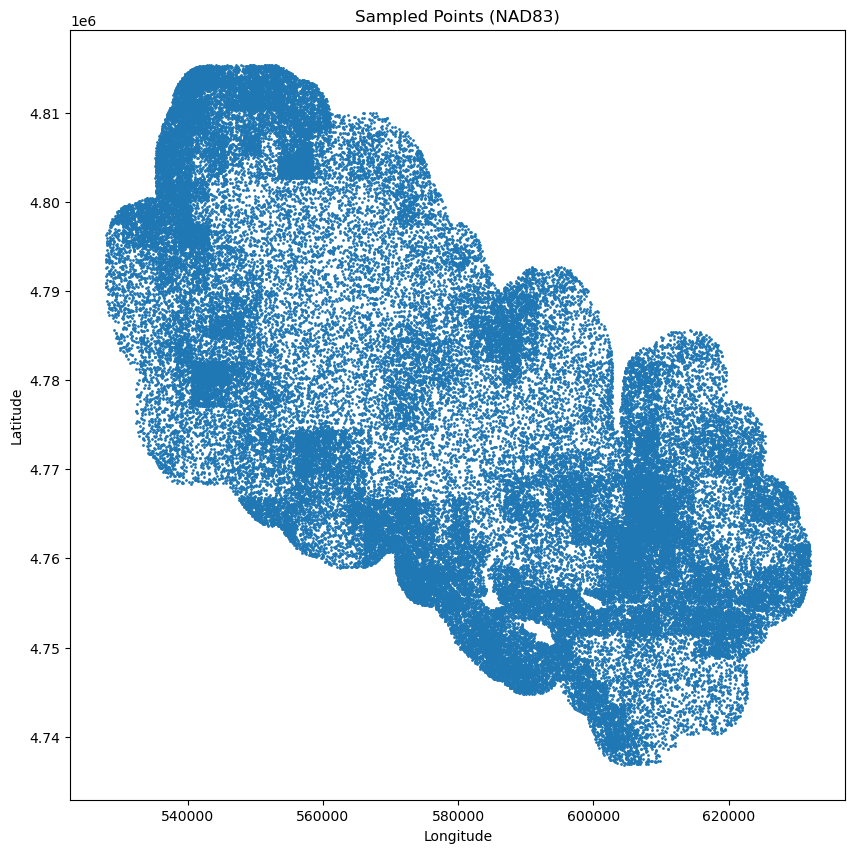

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("D:\My Drive\RAP10m_2025_points_k16_run5.csv")

plt.figure(figsize=(10,10))
plt.scatter(df["x_utm11n"], df["y_utm11n"], s=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sampled Points (NAD83)")
plt.show()

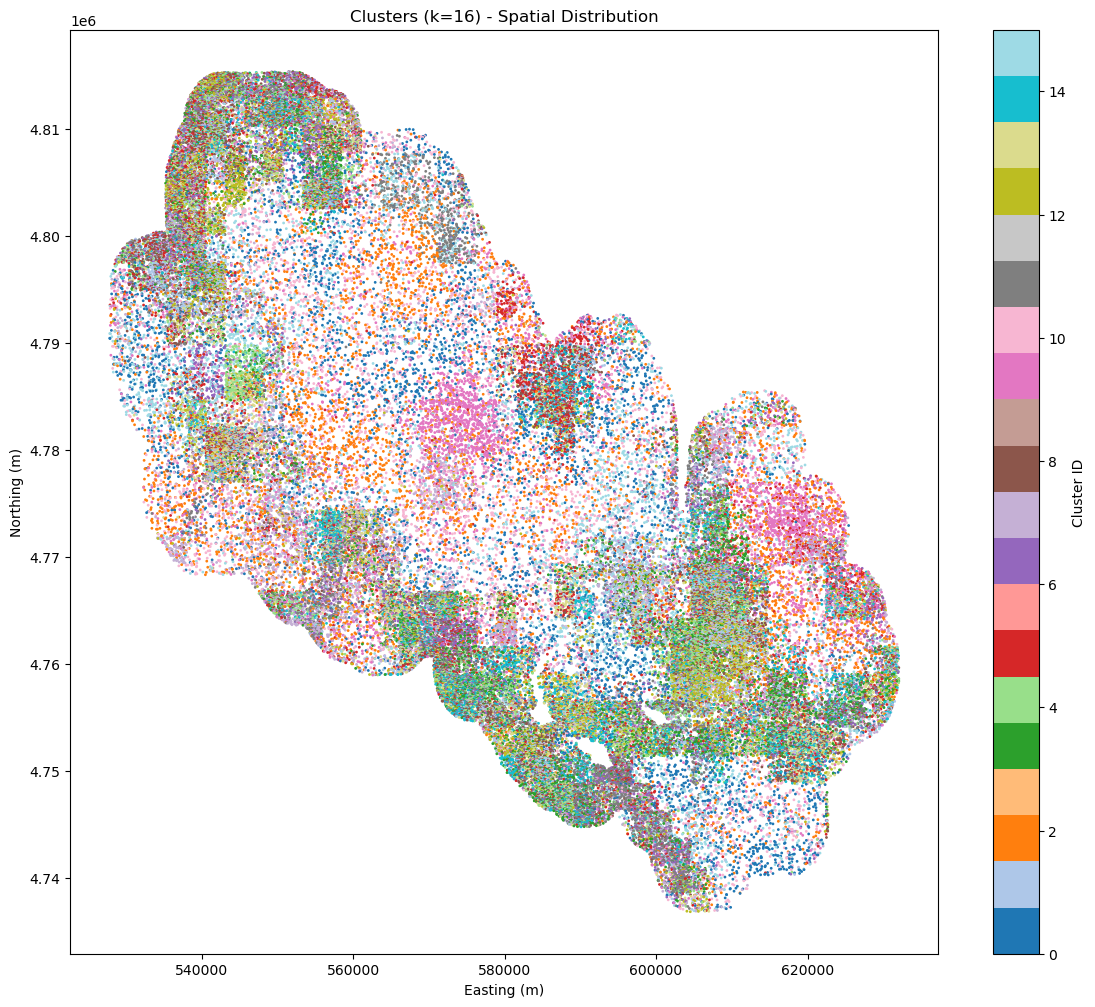

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("D:\My Drive\RAP10m_2025_points_k16_run5.csv")

plt.figure(figsize=(14,12))

sc = plt.scatter(
    df["x_utm11n"],
    df["y_utm11n"],
    c=df["cluster"],
    s=1,
    cmap="tab20"
)

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Clusters (k=16) - Spatial Distribution")

plt.colorbar(sc, label="Cluster ID")
plt.show()

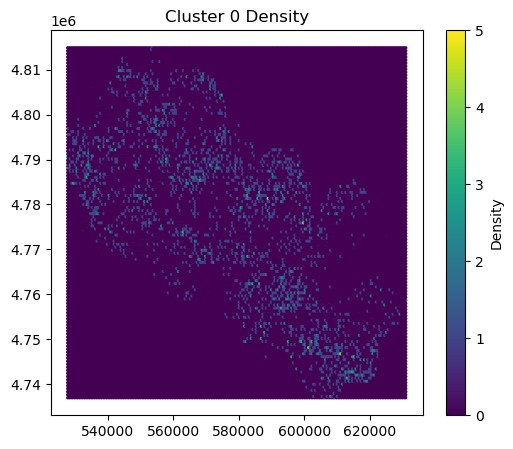

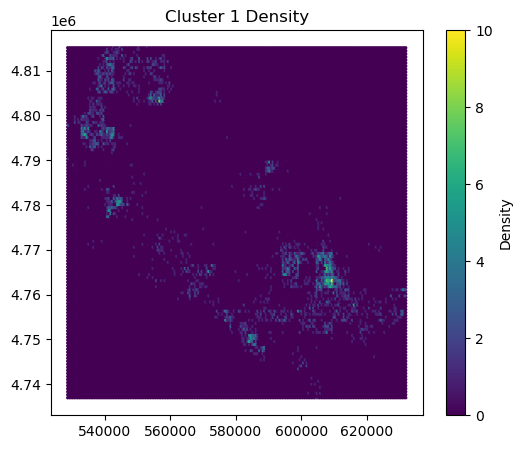

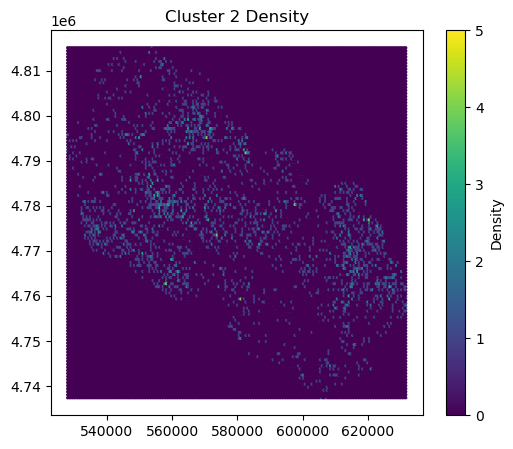

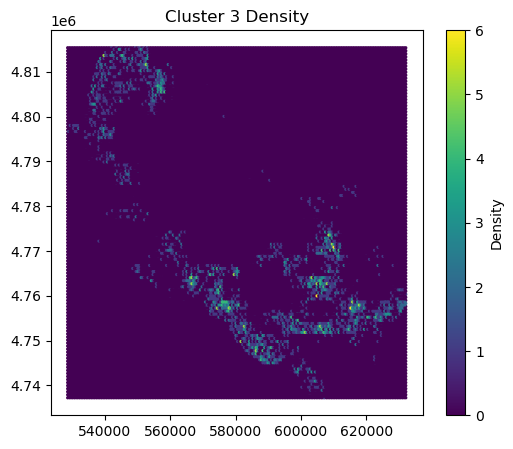

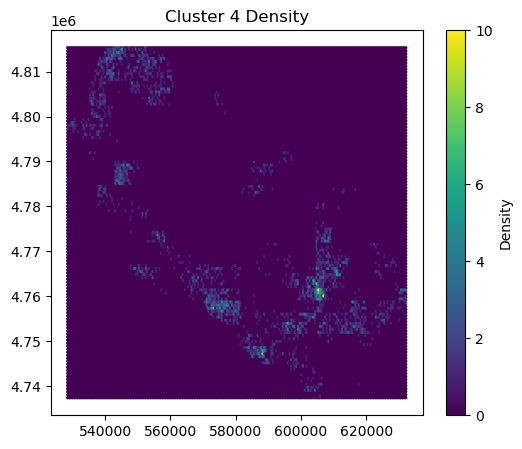

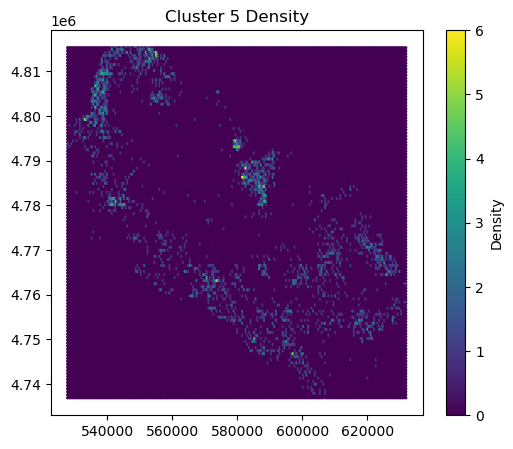

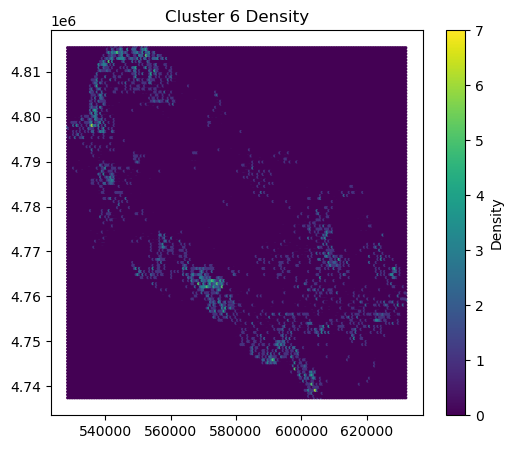

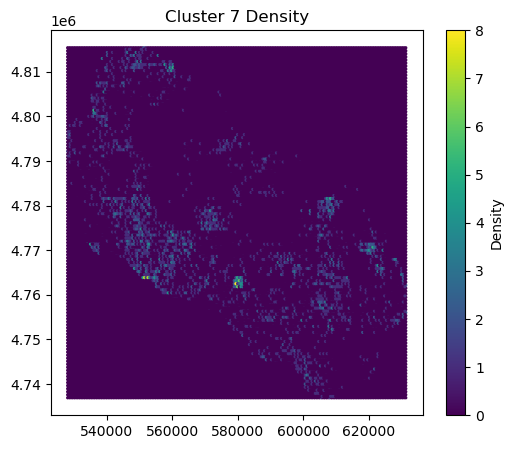

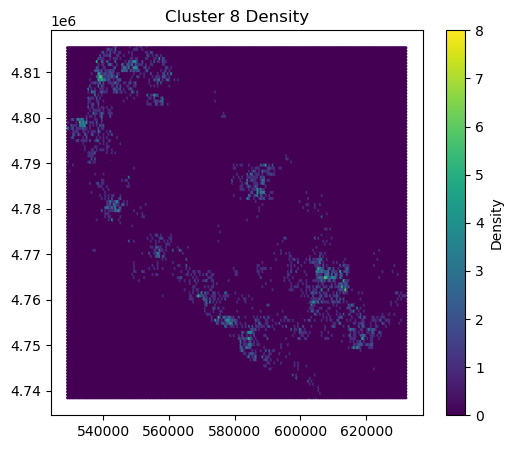

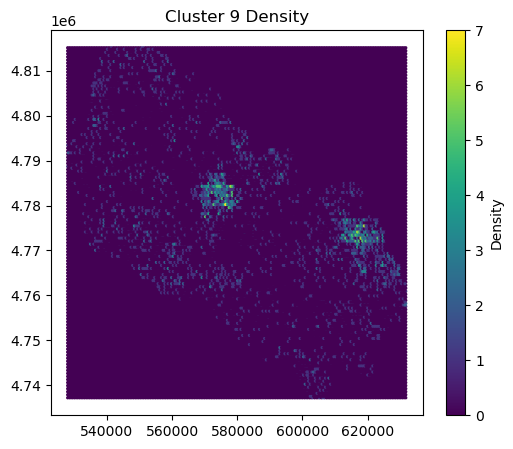

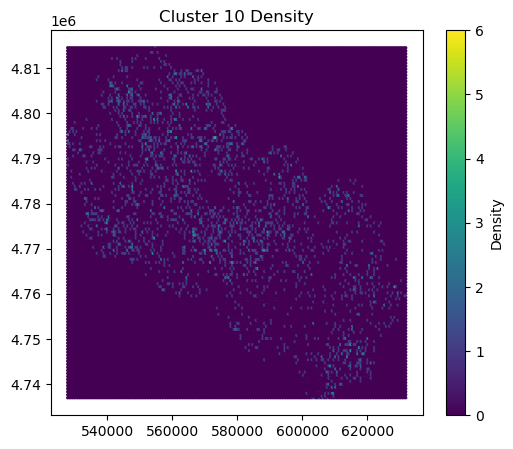

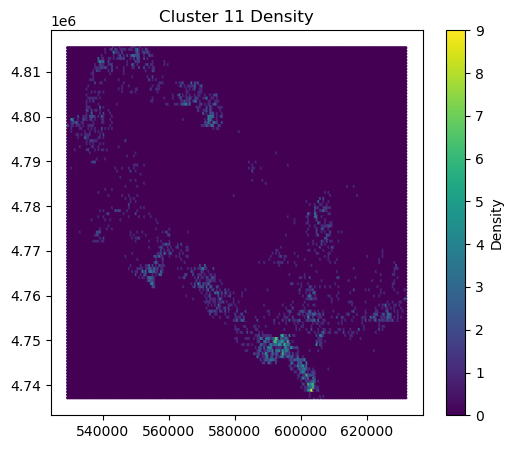

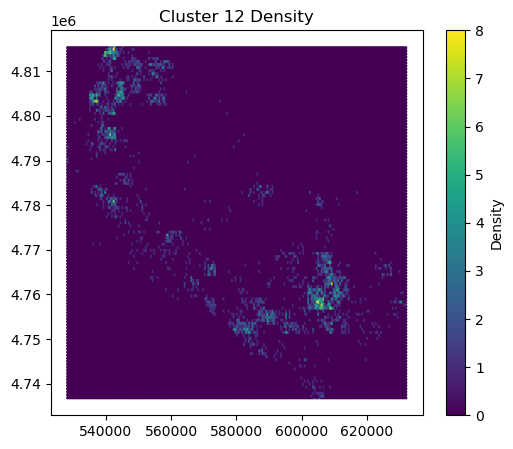

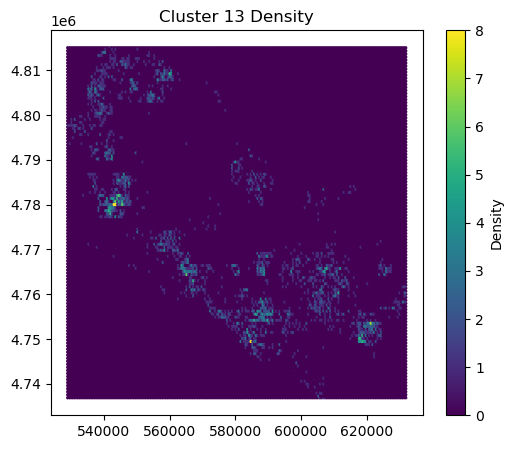

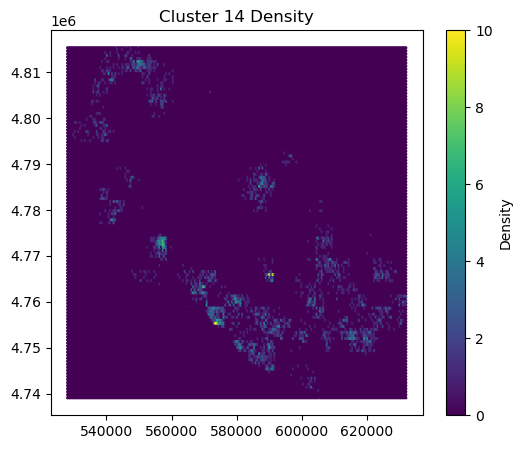

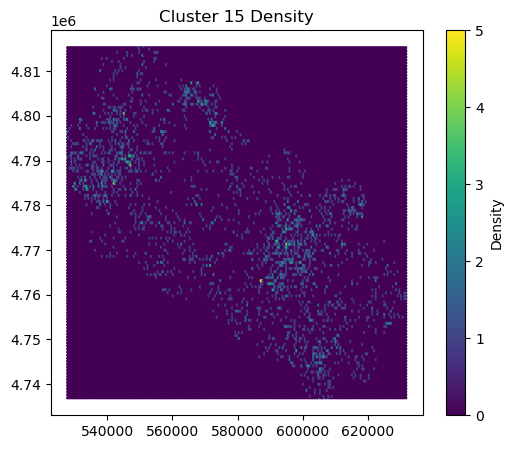

In [12]:
import numpy as np

for k in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == k]

    plt.figure(figsize=(6,5))
    plt.hexbin(
        subset["x_utm11n"],
        subset["y_utm11n"],
        gridsize=200,
        cmap="viridis"
    )
    plt.colorbar(label="Density")
    plt.title(f"Cluster {k} Density")
    plt.show()
    

In [1]:
#extract parent feature data from amp_phase_masked tif

from pathlib import Path
import numpy as np
import pandas as pd
import rasterio

# =============================================================================
# INPUTS
# =============================================================================

csv_file = Path(r"c:\NCA_DATA\cluster_v4_energy\energy_subset_5000_per_cluster_k16_run5.csv")

parent_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)

out_file = csv_file.parent / "energy_subset_5000_per_cluster_k16_run5_rawbands_intercept_energy_rmse.csv"

# =============================================================================
# SETTINGS
# =============================================================================

raw_band_names = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

# Based on the amp_phase raster structure you were using:
# each raw band occupies a 10-band block:
# [intercept, amp1, phase1, amp2, phase2, amp3, phase3, amp4, phase4, rmse]
block_size = 10

# 1-based raster band starts for each raw band block
# B2 starts at 1, B3 at 11, ..., B12 at 91
block_starts_1based = [1 + i * block_size for i in range(len(raw_band_names))]

# =============================================================================
# LOAD POINTS
# =============================================================================

df = pd.read_csv(csv_file)

required_cols = {"row", "col"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {missing}")

rows = df["row"].to_numpy(dtype=int)
cols = df["col"].to_numpy(dtype=int)

# =============================================================================
# EXTRACT
# =============================================================================

with rasterio.open(parent_raster) as src:
    nodata = src.nodata

    out_data = {}

    for band_name, start_1b in zip(raw_band_names, block_starts_1based):
        # convert to 0-based band indices for rasterio reads later if needed,
        # but rasterio.read uses 1-based band numbers directly
        intercept_band = start_1b
        amp_bands = [start_1b + 1, start_1b + 3, start_1b + 5, start_1b + 7]
        rmse_band = start_1b + 9

        # read only the needed bands
        intercept = src.read(intercept_band)[rows, cols].astype(np.float32)
        amp1 = src.read(amp_bands[0])[rows, cols].astype(np.float32)
        amp2 = src.read(amp_bands[1])[rows, cols].astype(np.float32)
        amp3 = src.read(amp_bands[2])[rows, cols].astype(np.float32)
        amp4 = src.read(amp_bands[3])[rows, cols].astype(np.float32)
        rmse = src.read(rmse_band)[rows, cols].astype(np.float32)

        # mask nodata if present
        if nodata is not None:
            intercept = np.where(intercept == nodata, np.nan, intercept)
            amp1 = np.where(amp1 == nodata, np.nan, amp1)
            amp2 = np.where(amp2 == nodata, np.nan, amp2)
            amp3 = np.where(amp3 == nodata, np.nan, amp3)
            amp4 = np.where(amp4 == nodata, np.nan, amp4)
            rmse = np.where(rmse == nodata, np.nan, rmse)

        # energy summary across harmonic orders 1..4
        energy = np.sqrt(amp1**2 + amp2**2 + amp3**2 + amp4**2)

        out_data[f"{band_name}_intercept"] = intercept
        out_data[f"{band_name}_energy"] = energy
        out_data[f"{band_name}_rmse"] = rmse

# =============================================================================
# SAVE
# =============================================================================

feature_df = pd.DataFrame(out_data)
out_df = pd.concat([df.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)
out_df.to_csv(out_file, index=False)

print(f"Wrote: {out_file}")
print(f"Rows: {out_df.shape[0]}")
print(f"Columns: {out_df.shape[1]}")
print("\nExtracted columns:")
print(feature_df.columns.tolist())

Wrote: c:\NCA_DATA\cluster_v4_energy\energy_subset_5000_per_cluster_k16_run5_rawbands_intercept_energy_rmse.csv
Rows: 80000
Columns: 36

Extracted columns:
['B2_intercept', 'B2_energy', 'B2_rmse', 'B3_intercept', 'B3_energy', 'B3_rmse', 'B4_intercept', 'B4_energy', 'B4_rmse', 'B5_intercept', 'B5_energy', 'B5_rmse', 'B6_intercept', 'B6_energy', 'B6_rmse', 'B7_intercept', 'B7_energy', 'B7_rmse', 'B8_intercept', 'B8_energy', 'B8_rmse', 'B8A_intercept', 'B8A_energy', 'B8A_rmse', 'B11_intercept', 'B11_energy', 'B11_rmse', 'B12_intercept', 'B12_energy', 'B12_rmse']


In [13]:
import pandas as pd

df = pd.read_csv("D:\My Drive\RAP10m_2025_points_k16_run5.csv")

cols = ["AFG","BGR","LTR","PFG","SHR","TRE"]

df["valid"] = (
    (df["col_sum"] > 50) &      # too low → masked / invalid
    (df["col_sum"] < 150)    # too high → overlap artifacts
    #(df["BGR"] > 0)             # bare ground must exist in this system
)

print("Valid fraction:", df["valid"].mean())

raw_summary = df.groupby("cluster")[cols + ["col_sum"]].mean()
raw_counts = df.groupby("cluster").size()

raw_summary["n_raw"] = raw_counts

print(raw_summary)

df_clean = df[df["valid"]].copy()
clean_summary = df_clean.groupby("cluster")[cols + ["col_sum"]].mean()
counts_clean = df_clean.groupby("cluster").size()

clean_summary["n_clean"] = counts_clean

# add valid fraction per cluster
valid_fraction = df.groupby("cluster")["valid"].mean()
clean_summary["valid_fraction"] = valid_fraction

print(clean_summary)

bad_clusters = clean_summary[
    (clean_summary["valid_fraction"] < 0.5) |
    (clean_summary["col_sum"] < 50)
].index.tolist()

print("Bad clusters:", bad_clusters)
good_clusters = clean_summary[
    (clean_summary["valid_fraction"] > 0.8) &
    (clean_summary["col_sum"].between(60, 120))
].index.tolist()

print("Good clusters:", good_clusters)

Valid fraction: 0.6591125
             AFG      BGR      LTR      PFG     SHR     TRE  col_sum  n_raw
cluster                                                                    
0        36.9210   7.9038  15.1338  17.7222  6.1974  1.0364  84.9146   5000
1        21.1310   5.3736   7.9274   8.6290  3.5256  0.9372  47.5238   5000
2        30.1768  12.0438  16.3452  18.1242  7.6500  1.0462  85.3862   5000
3        20.0212   5.3292   7.8664  10.2154  3.8498  0.9610  48.2430   5000
4        18.6512   5.2856   7.3466  10.0178  3.6086  0.9468  45.8566   5000
5        22.1000   7.7480   9.5632  12.3846  4.2134  0.9872  56.9964   5000
6        20.9688   6.9290   8.5290  13.5236  4.5476  1.0726  55.5706   5000
7        25.7368  11.0948  12.0862  13.6896  6.6142  0.8968  70.1184   5000
8        20.6718   5.6740   7.9490   9.2862  3.4288  0.8682  47.8780   5000
9        26.4830  15.7618  15.7204  17.7496  5.7950  0.8524  82.3622   5000
10       34.3854   9.4044  16.0620  18.4936  6.8536  0.9828  8

need to normalize the RAP data since the clean data is about 10% under

In [18]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

cols = ["AFG","BGR","LTR","PFG","SHR","TRE"]

# df_clean already filtered using your validity rule
df_clean_norm = df_clean.copy()
df_clean_norm[cols] = df_clean_norm[cols].div(df_clean_norm["col_sum"], axis=0)
print(df_clean_norm)

                 system:index       AFG       BGR       LTR       PFG  \
7      0000000000000000df35_0  0.509091  0.081818  0.209091  0.190909   
8      000000000000000087d9_0  0.436782  0.137931  0.103448  0.229885   
9      00000000000000005560_0  0.344828  0.068966  0.120690  0.344828   
10     0000000000000001186b_0  0.258824  0.176471  0.176471  0.282353   
16     00000000000000007d4a_0  0.060606  0.090909  0.075758  0.742424   
...                       ...       ...       ...       ...       ...   
79995  0000000000000000f3fa_0  0.774194  0.043011  0.129032  0.000000   
79996  00000000000000011131_0  0.244444  0.088889  0.144444  0.455556   
79997  00000000000000010a36_0  0.915888  0.000000  0.084112  0.000000   
79998  0000000000000000f47c_0  0.500000  0.093023  0.151163  0.162791   
79999  0000000000000000ef32_0  0.176471  0.164706  0.188235  0.282353   

            SHR       TRE  cluster  col_sum   col    point_id   row  x_utm11n  \
7      0.009091  0.000000       11      11

Explained variance: [0.60791857 0.27702631]
          PC1       PC2
AFG  0.863857  0.070171
BGR -0.334340 -0.555835
LTR -0.016766 -0.110039
PFG -0.346913  0.797431
SHR -0.144512 -0.195128
TRE -0.021326 -0.006600


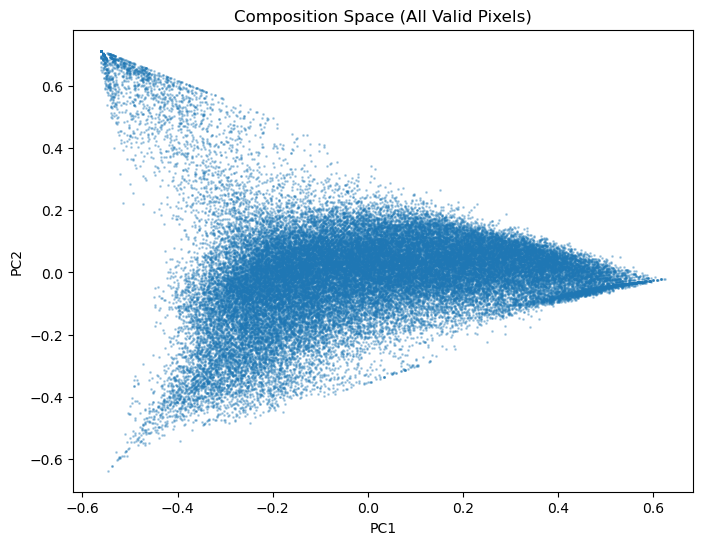

NameError: name 'PC1' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cols = ["AFG","BGR","LTR","PFG","SHR","TRE"]

# ensure normalized (you already did this)
X = df_clean_norm[cols].values

pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

df_clean_norm["PC1"] = pcs[:, 0]
df_clean_norm["PC2"] = pcs[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_.T,
    index=cols,
    columns=["PC1","PC2"]
)

print(loadings)
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean_norm["PC1"],
    df_clean_norm["PC2"],
    s=1,
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Composition Space (All Valid Pixels)")
plt.show()



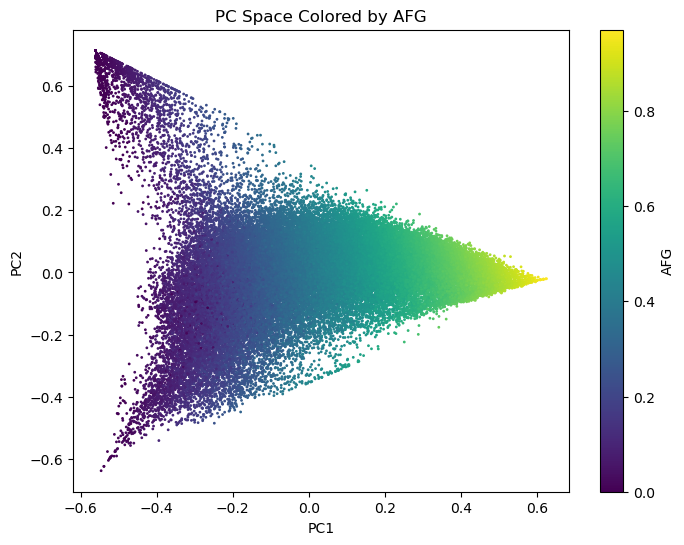

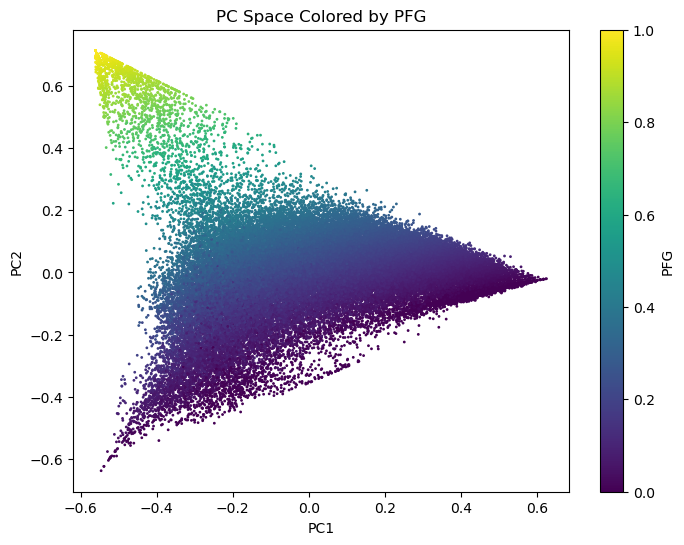

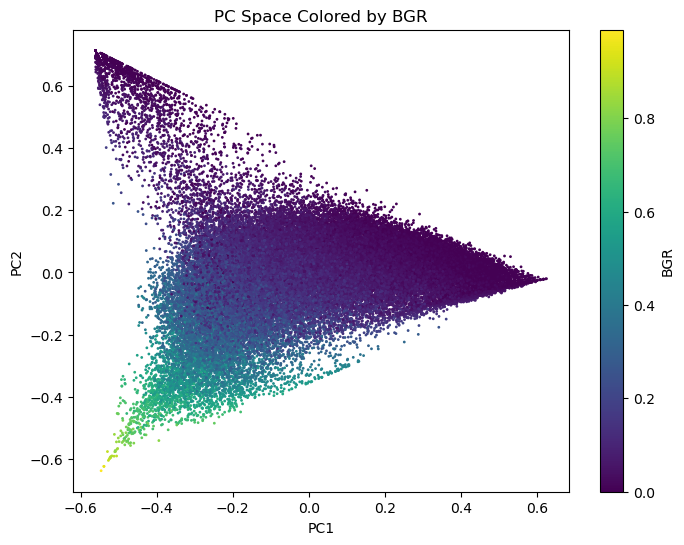

In [23]:
import matplotlib.pyplot as plt

# AFG
plt.figure(figsize=(8,6))
plt.scatter(
    df_clean_norm["PC1"],
    df_clean_norm["PC2"],
    c=df_clean_norm["AFG"],
    s=1,
    cmap="viridis"
)
plt.colorbar(label="AFG")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC Space Colored by AFG")
plt.show()


# PFG
plt.figure(figsize=(8,6))
plt.scatter(
    df_clean_norm["PC1"],
    df_clean_norm["PC2"],
    c=df_clean_norm["PFG"],
    s=1,
    cmap="viridis"
)
plt.colorbar(label="PFG")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC Space Colored by PFG")
plt.show()


# BGR
plt.figure(figsize=(8,6))
plt.scatter(
    df_clean_norm["PC1"],
    df_clean_norm["PC2"],
    c=df_clean_norm["BGR"],
    s=1,
    cmap="viridis"
)
plt.colorbar(label="BGR")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC Space Colored by BGR")
plt.show()

Explained variance: [0.40746397 0.39689165]
Total explained: 0.8043556

PC1 min/max: -3.7339087 978.8008
PC2 min/max: -2629.4087 5.004333

PC1 percentiles: [-3.73390865e+00 -2.90786737e+00 -2.50542918e+00 -9.36690450e-01
  1.02363704e+01  1.36229632e+01  9.78800781e+02]
PC2 percentiles: [-2.62940869e+03 -1.06575336e+00 -9.15448788e-01 -3.39187384e-01
  3.74703460e+00  5.00433302e+00  5.00433302e+00]


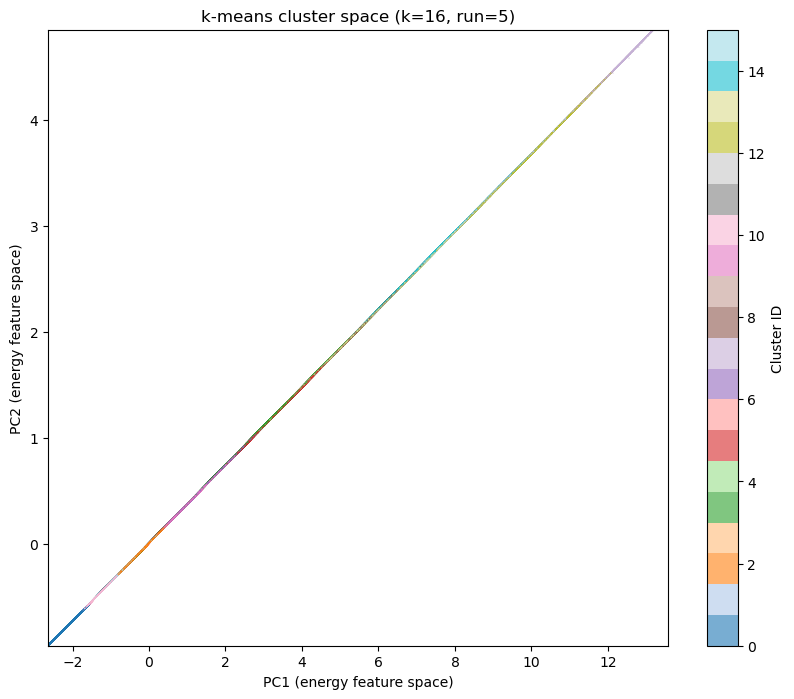

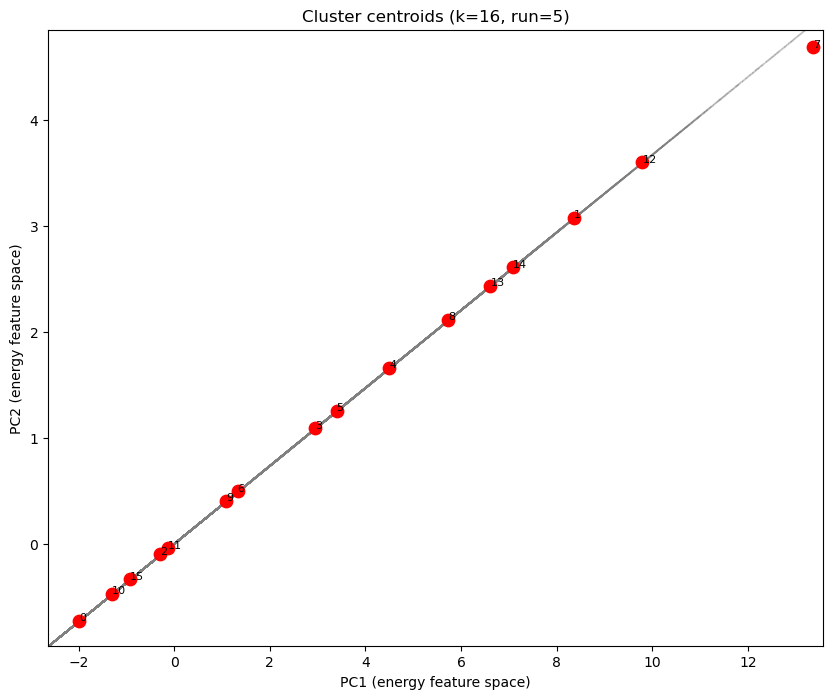

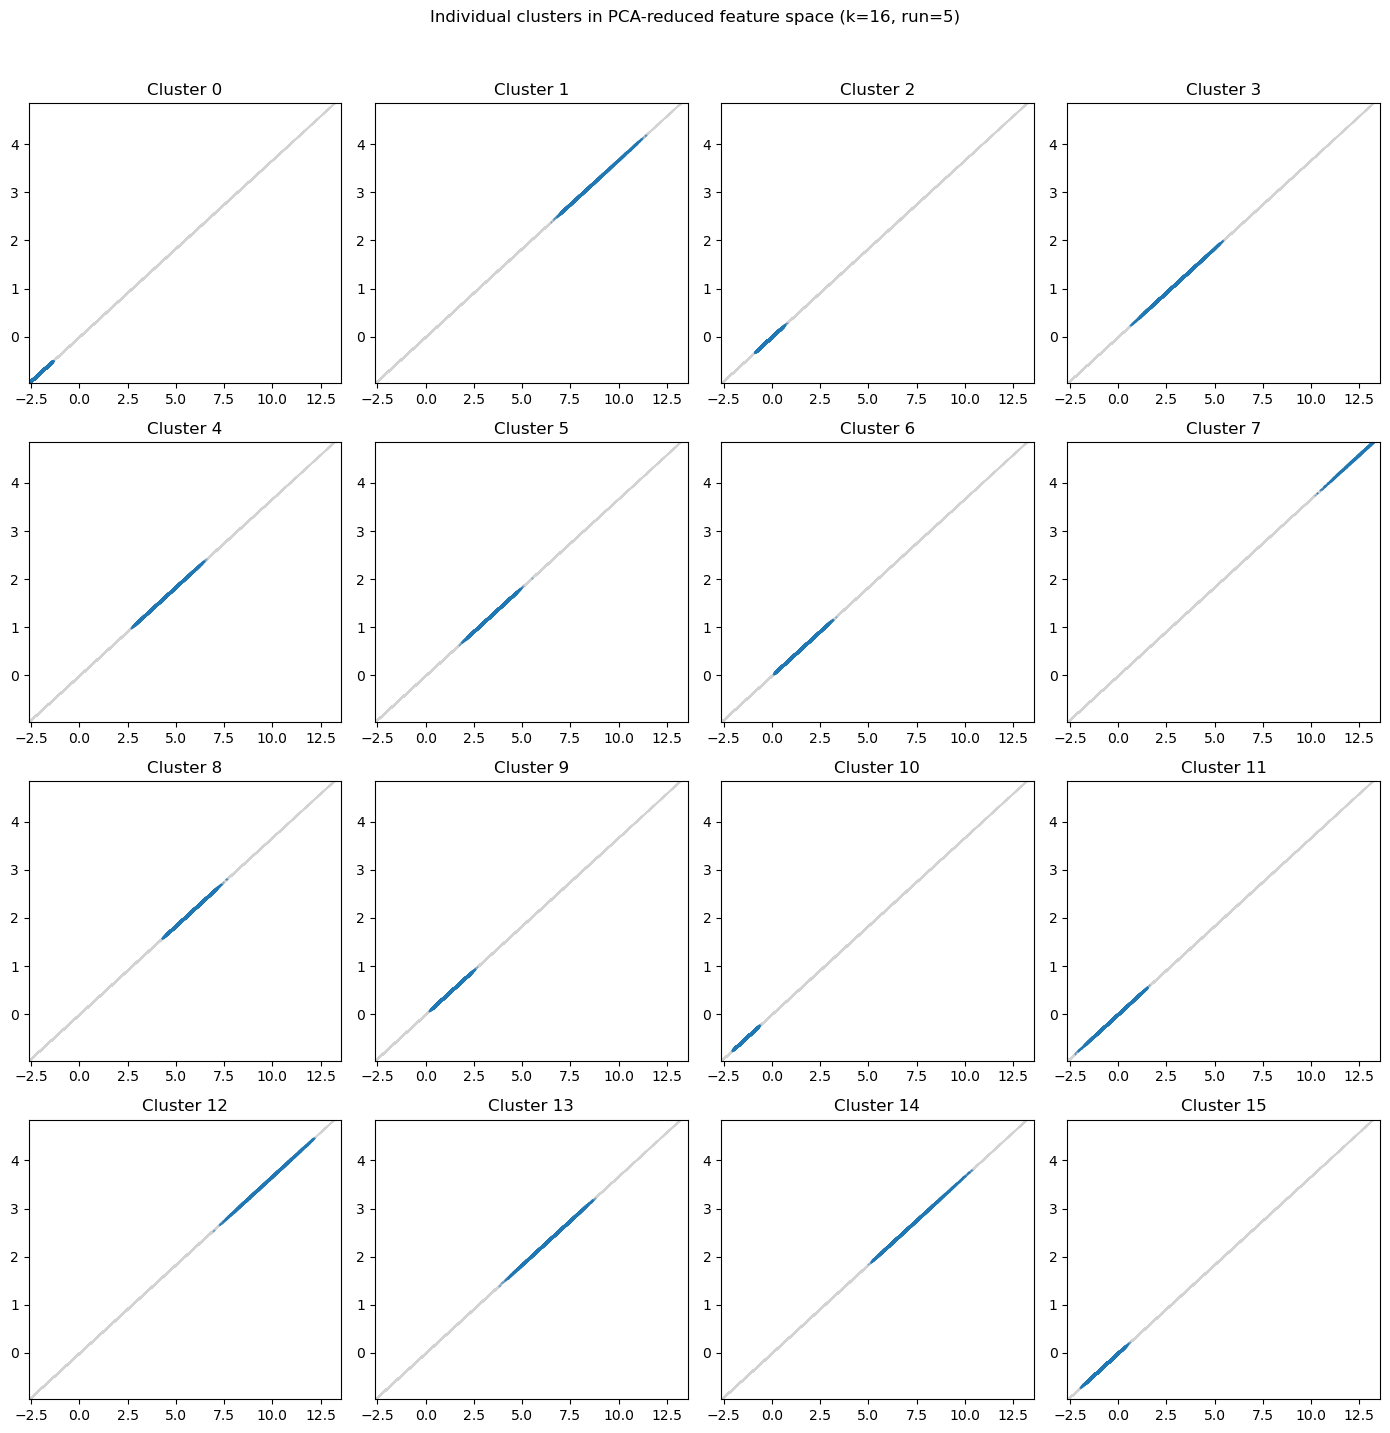

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =============================================================================
# LOAD DATA (ASSUMES THESE PATHS ARE ALREADY CORRECT IN YOUR ENVIRONMENT)
# =============================================================================

X = np.load(r"C:\NCA_DATA\cluster_v3\X_energy_1M_clipped.npy")
bundle = np.load(r"C:\NCA_DATA\cluster_v4_energy_k16_deepdive\energy_k16_bundle.npz")

run_to_plot = 5

labels = bundle[f"labels_run{run_to_plot}"]
centers = bundle[f"centers_run{run_to_plot}"]

# =============================================================================
# STANDARDIZE + PCA
# =============================================================================

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(Xz)
centers_pca = pca.transform(centers)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())

# =============================================================================
# DIAGNOSE OUTLIERS
# =============================================================================

print("\nPC1 min/max:", pcs[:, 0].min(), pcs[:, 0].max())
print("PC2 min/max:", pcs[:, 1].min(), pcs[:, 1].max())

print("\nPC1 percentiles:", np.percentile(pcs[:, 0], [0, 0.1, 1, 50, 99, 99.9, 100]))
print("PC2 percentiles:", np.percentile(pcs[:, 1], [0, 0.1, 1, 50, 99, 99.9, 100]))

# =============================================================================
# ROBUST AXIS LIMITS (IGNORE EXTREME OUTLIERS)
# =============================================================================

x_lo, x_hi = np.percentile(pcs[:, 0], [0.5, 99.5])
y_lo, y_hi = np.percentile(pcs[:, 1], [0.5, 99.5])

# =============================================================================
# FIGURE 1: PCA COLORED BY CLUSTER
# =============================================================================

plt.figure(figsize=(10, 8))

sc = plt.scatter(
    pcs[:, 0],
    pcs[:, 1],
    c=labels,
    s=1,
    cmap="tab20",
    alpha=0.6,
    linewidths=0,
    rasterized=True
)

plt.xlabel("PC1 (energy feature space)")
plt.ylabel("PC2 (energy feature space)")
plt.title(f"k-means cluster space (k=16, run={run_to_plot})")
plt.xlim(x_lo, x_hi)
plt.ylim(y_lo, y_hi)
plt.colorbar(sc, label="Cluster ID")
plt.show()

# =============================================================================
# FIGURE 2: PCA WITH CENTROIDS
# =============================================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    pcs[:, 0],
    pcs[:, 1],
    s=1,
    alpha=0.03,
    color="gray",
    linewidths=0,
    rasterized=True
)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    color="red",
    s=80
)

for i, (x, y) in enumerate(centers_pca):
    plt.text(x, y, str(i), fontsize=8)

plt.xlabel("PC1 (energy feature space)")
plt.ylabel("PC2 (energy feature space)")
plt.title(f"Cluster centroids (k=16, run={run_to_plot})")
plt.xlim(x_lo, x_hi)
plt.ylim(y_lo, y_hi)
plt.show()

# =============================================================================
# FIGURE 3: INDIVIDUAL CLUSTERS
# =============================================================================

unique_clusters = np.sort(np.unique(labels))
n_clusters = len(unique_clusters)

ncols = 4
nrows = int(np.ceil(n_clusters / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), squeeze=False)

for ax, cl in zip(axes.flat, unique_clusters):
    idx = labels == cl

    # background
    ax.scatter(
        pcs[:, 0],
        pcs[:, 1],
        s=1,
        alpha=0.03,
        color="lightgray",
        linewidths=0,
        rasterized=True
    )

    # cluster
    ax.scatter(
        pcs[idx, 0],
        pcs[idx, 1],
        s=2,
        alpha=0.5,
        linewidths=0,
        rasterized=True
    )

    ax.set_title(f"Cluster {cl}")
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)

# turn off unused axes
for ax in axes.flat[n_clusters:]:
    ax.axis("off")

plt.suptitle(
    f"Individual clusters in PCA-reduced feature space (k=16, run={run_to_plot})",
    y=1.02
)

plt.tight_layout()
plt.show()

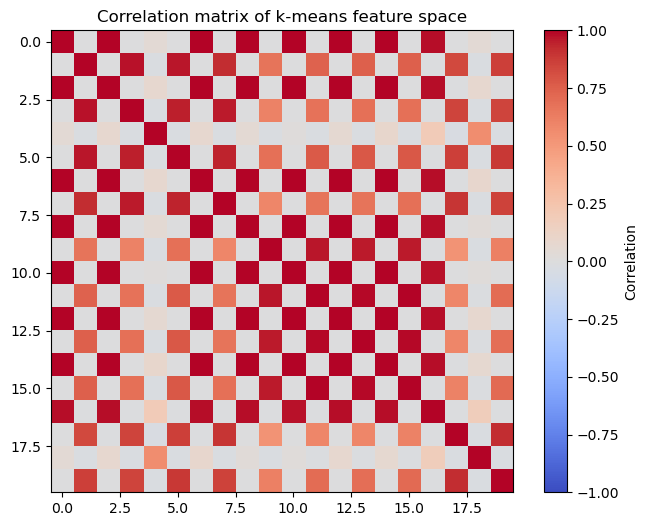

In [26]:
import numpy as np
import matplotlib.pyplot as plt

corr = np.corrcoef(Xz, rowvar=False)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Correlation matrix of k-means feature space")
plt.show()

In [27]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(Xz)

plt.figure(figsize=(10, 8))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels,
    s=1,
    cmap="tab20",
    alpha=0.7,
    linewidths=0
)
plt.title("t-SNE of k-means feature space (cluster structure)")
plt.colorbar(label="Cluster ID")
plt.show()

c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\scottfordham\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in ru

KeyboardInterrupt: 

c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


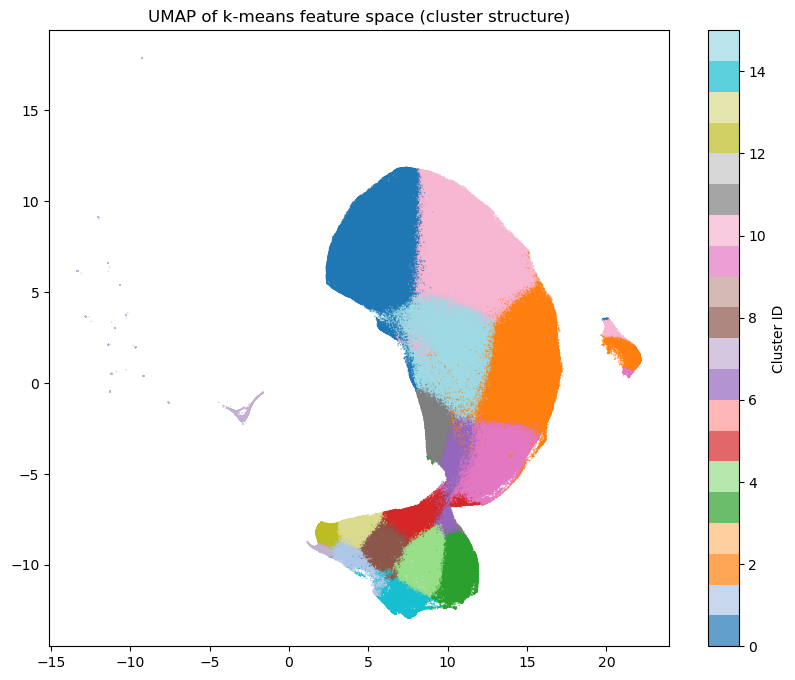

In [32]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, n_neighbors=50, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(Xz)

plt.figure(figsize=(10, 8))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    s=1,
    cmap="tab20",
    alpha=0.7,
    linewidths=0
)
plt.title("UMAP of k-means feature space (cluster structure)")
plt.colorbar(label="Cluster ID")
plt.show()

PCA (20D) explained variance: 0.99999994


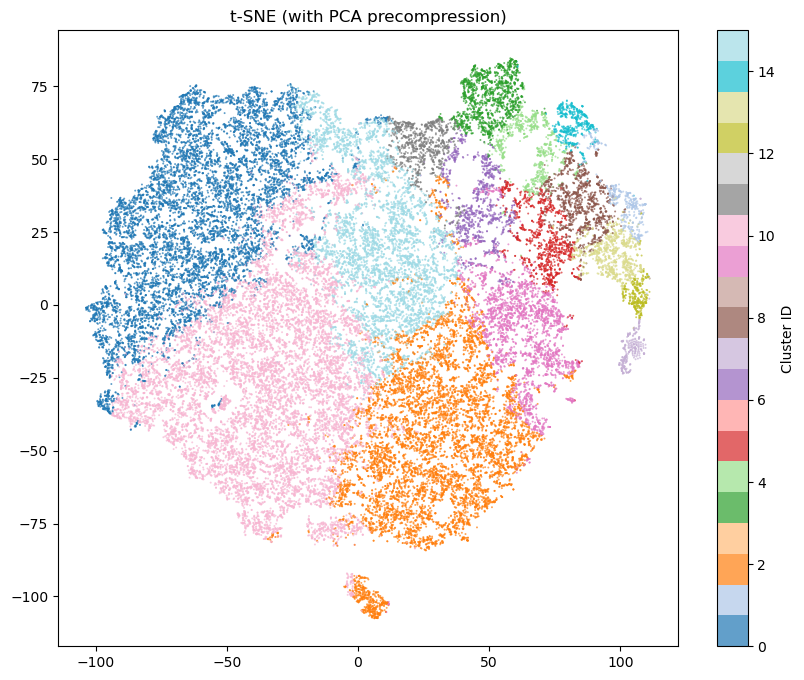

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -------------------------------------------------------------------
# SUBSAMPLE
# -------------------------------------------------------------------
rng = np.random.default_rng(42)
n_vis = 50000

idx = rng.choice(Xz.shape[0], size=min(n_vis, Xz.shape[0]), replace=False)

X_vis = Xz[idx]
labels_vis = labels[idx]

# -------------------------------------------------------------------
# PCA PRECOMPRESSION (CRITICAL)
# -------------------------------------------------------------------
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_vis)

print("PCA (20D) explained variance:", pca.explained_variance_ratio_.sum())

# -------------------------------------------------------------------
# T-SNE
# -------------------------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=50,
    max_iter=1000,
    init="pca",
    learning_rate="auto",
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

# -------------------------------------------------------------------
# PLOT
# -------------------------------------------------------------------
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels_vis,
    s=2,
    cmap="tab20",
    alpha=0.7,
    linewidths=0
)

plt.title("t-SNE (with PCA precompression)")
plt.colorbar(sc, label="Cluster ID")
plt.show()

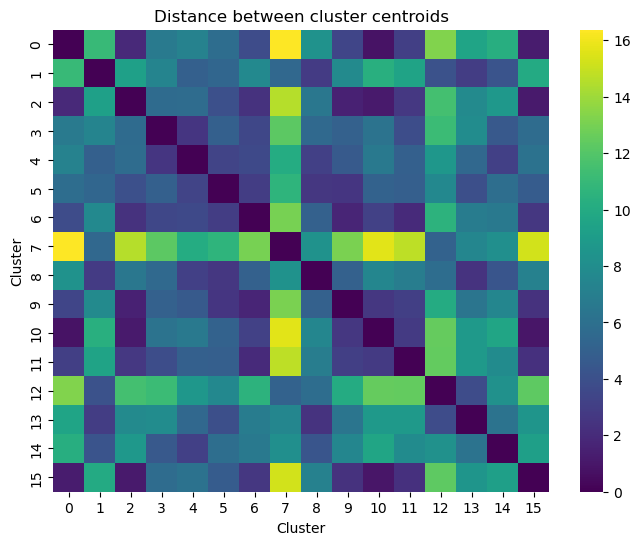

In [30]:
from scipy.spatial.distance import cdist
import seaborn as sns

dist_matrix = cdist(centers, centers)

plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrix, cmap="viridis")
plt.title("Distance between cluster centroids")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()

In [35]:
from pathlib import Path
import pandas as pd

# =============================================================================
# INPUT FILES
# =============================================================================

rap_file = Path(r"D:\My Drive\RAP10m_2025_points_k16_run5.csv")
energy_file = Path(r"C:\NCA_DATA\cluster_v4_energy\energy_subset_5000_per_cluster_k16_run5_rawbands_intercept_energy_rmse.csv")

out_file = Path(r"D:\My Drive\rap_energy_joined_for_brms.csv")

# =============================================================================
# LOAD
# =============================================================================

rap = pd.read_csv(rap_file)
energy = pd.read_csv(energy_file)

print("RAP shape:", rap.shape)
print("Energy shape:", energy.shape)

# =============================================================================
# REBUILD valid FLAG IF MISSING
# =============================================================================

if "valid" not in rap.columns:
    rap["valid"] = (
        (rap["col_sum"] > 50) &
        (rap["col_sum"] < 150)
    )

# =============================================================================
# HARMONIZE COORDINATE NAMES
# =============================================================================

if "x_utm11n" not in energy.columns and "x" in energy.columns:
    energy = energy.rename(columns={"x": "x_utm11n"})

if "y_utm11n" not in energy.columns and "y" in energy.columns:
    energy = energy.rename(columns={"y": "y_utm11n"})

# =============================================================================
# OPTIONAL: KEEP ONLY WHAT YOU NEED
# =============================================================================

rap_cols = [
    "point_id", "cluster", "col_sum", "valid",
    "AFG", "BGR", "LTR", "PFG", "SHR", "TRE"
]

energy_cols = [
    "point_id", "row", "col", "x_utm11n", "y_utm11n",
    "B2_intercept", "B2_energy", "B2_rmse",
    "B3_intercept", "B3_energy", "B3_rmse",
    "B4_intercept", "B4_energy", "B4_rmse",
    "B5_intercept", "B5_energy", "B5_rmse",
    "B6_intercept", "B6_energy", "B6_rmse",
    "B7_intercept", "B7_energy", "B7_rmse",
    "B8_intercept", "B8_energy", "B8_rmse",
    "B8A_intercept", "B8A_energy", "B8A_rmse",
    "B11_intercept", "B11_energy", "B11_rmse",
    "B12_intercept", "B12_energy", "B12_rmse"
]

missing_rap = [c for c in rap_cols if c not in rap.columns]
missing_energy = [c for c in energy_cols if c not in energy.columns]

if missing_rap:
    raise ValueError(f"Missing RAP columns: {missing_rap}")
if missing_energy:
    raise ValueError(f"Missing energy columns: {missing_energy}")

rap = rap[rap_cols].copy()
energy = energy[energy_cols].copy()

# =============================================================================
# CLEAN TYPES
# =============================================================================

rap["point_id"] = rap["point_id"].astype(str)
energy["point_id"] = energy["point_id"].astype(str)

# =============================================================================
# CHECK DUPLICATES
# =============================================================================

rap_dups = rap["point_id"].duplicated().sum()
energy_dups = energy["point_id"].duplicated().sum()

print("Duplicate point_id in RAP:", rap_dups)
print("Duplicate point_id in energy:", energy_dups)

if rap_dups > 0:
    raise ValueError("RAP file has duplicate point_id values.")
if energy_dups > 0:
    raise ValueError("Energy file has duplicate point_id values.")

# =============================================================================
# FILTER TO VALID RAP PIXELS
# =============================================================================

rap_valid = rap[rap["valid"]].copy()
print("RAP valid shape:", rap_valid.shape)

# =============================================================================
# JOIN
# =============================================================================

joined = rap_valid.merge(
    energy,
    on="point_id",
    how="inner",
    validate="one_to_one"
)

print("Joined shape:", joined.shape)

# =============================================================================
# CHECK FOR LOSSES
# =============================================================================

rap_only = set(rap_valid["point_id"]) - set(joined["point_id"])
energy_only = set(energy["point_id"]) - set(joined["point_id"])

print("Valid RAP points not found in energy:", len(rap_only))
print("Energy points not found in valid RAP:", len(energy_only))

# =============================================================================
# SAVE
# =============================================================================

joined.to_csv(out_file, index=False)
print(f"Wrote: {out_file}")



RAP shape: (80000, 15)
Energy shape: (80000, 36)
Duplicate point_id in RAP: 0
Duplicate point_id in energy: 0
RAP valid shape: (52729, 10)
Joined shape: (52729, 44)
Valid RAP points not found in energy: 0
Energy points not found in valid RAP: 27271
Wrote: D:\My Drive\rap_energy_joined_for_brms.csv


need to extract the indices information to join to this table and then produce modelable objects (simpler models)

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio

# =============================================================================
# INPUT FILES
# =============================================================================

rap_file = Path(r"D:\My Drive\RAP10m_2025_points_k16_run5.csv")

energy_file = Path(
    r"C:\NCA_DATA\Clustering\cluster_v4_energy\energy_subset_5000_per_cluster_k16_run5_rawbands_intercept_energy_rmse.csv"
)

harmonic_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)

out_file = Path(r"D:\My Drive\rap_energy_joined_for_brms_wIndices.csv")

# =============================================================================
# LOAD
# =============================================================================

rap = pd.read_csv(rap_file)
energy = pd.read_csv(energy_file)

print("RAP shape:", rap.shape)
print("Energy shape:", energy.shape)

# =============================================================================
# REBUILD VALID FLAG IF MISSING
# =============================================================================

if "valid" not in rap.columns:
    rap["valid"] = (
        (rap["col_sum"] > 50) &
        (rap["col_sum"] < 150)
    )

# =============================================================================
# HARMONIZE COORDINATE NAMES
# =============================================================================

if "x_utm11n" not in energy.columns and "x" in energy.columns:
    energy = energy.rename(columns={"x": "x_utm11n"})

if "y_utm11n" not in energy.columns and "y" in energy.columns:
    energy = energy.rename(columns={"y": "y_utm11n"})

# =============================================================================
# KEEP REQUIRED COLUMNS
# =============================================================================

rap_cols = [
    "point_id", "cluster", "col_sum", "valid",
    "AFG", "BGR", "LTR", "PFG", "SHR", "TRE"
]

energy_cols = [
    "point_id", "row", "col", "x_utm11n", "y_utm11n",
    "B2_intercept", "B2_energy", "B2_rmse",
    "B3_intercept", "B3_energy", "B3_rmse",
    "B4_intercept", "B4_energy", "B4_rmse",
    "B5_intercept", "B5_energy", "B5_rmse",
    "B6_intercept", "B6_energy", "B6_rmse",
    "B7_intercept", "B7_energy", "B7_rmse",
    "B8_intercept", "B8_energy", "B8_rmse",
    "B8A_intercept", "B8A_energy", "B8A_rmse",
    "B11_intercept", "B11_energy", "B11_rmse",
    "B12_intercept", "B12_energy", "B12_rmse"
]

missing_rap = [c for c in rap_cols if c not in rap.columns]
missing_energy = [c for c in energy_cols if c not in energy.columns]

if missing_rap:
    raise ValueError(f"Missing RAP columns: {missing_rap}")

if missing_energy:
    raise ValueError(f"Missing energy columns: {missing_energy}")

rap = rap[rap_cols].copy()
energy = energy[energy_cols].copy()

# =============================================================================
# CLEAN TYPES
# =============================================================================

rap["point_id"] = rap["point_id"].astype(str)
energy["point_id"] = energy["point_id"].astype(str)

# =============================================================================
# CHECK DUPLICATES
# =============================================================================

rap_dups = rap["point_id"].duplicated().sum()
energy_dups = energy["point_id"].duplicated().sum()

print("Duplicate point_id in RAP:", rap_dups)
print("Duplicate point_id in energy:", energy_dups)

if rap_dups > 0:
    raise ValueError("RAP file has duplicate point_id values.")

if energy_dups > 0:
    raise ValueError("Energy file has duplicate point_id values.")

# =============================================================================
# FILTER TO VALID RAP PIXELS
# =============================================================================

rap_valid = rap[rap["valid"]].copy()
print("RAP valid shape:", rap_valid.shape)

# =============================================================================
# JOIN RAP + ENERGY TABLES
# =============================================================================

joined = rap_valid.merge(
    energy,
    on="point_id",
    how="inner",
    validate="one_to_one"
)

print("Joined shape before index extraction:", joined.shape)

rap_only = set(rap_valid["point_id"]) - set(joined["point_id"])
energy_only = set(energy["point_id"]) - set(joined["point_id"])

print("Valid RAP points not found in energy:", len(rap_only))
print("Energy points not found in valid RAP:", len(energy_only))

# =============================================================================
# EXTRACT INDEX INTERCEPT, A1, AND 4-HARMONIC ENERGY
# =============================================================================

index_names = ["NDVI", "NDMI", "BSI", "NDRE"]

with rasterio.open(harmonic_raster) as src:
    band_names = list(src.descriptions)

    needed = {
        idx: {
            "intercept": None,
            "A1": None,
            "A2": None,
            "A3": None,
            "A4": None,
        }
        for idx in index_names
    }

    for band_i, name in enumerate(band_names, start=1):
        if name is None:
            continue

        for idx in index_names:
            if name == f"beta0_{idx}":
                needed[idx]["intercept"] = band_i
            elif name == f"A1_{idx}":
                needed[idx]["A1"] = band_i
            elif name == f"A2_{idx}":
                needed[idx]["A2"] = band_i
            elif name == f"A3_{idx}":
                needed[idx]["A3"] = band_i
            elif name == f"A4_{idx}":
                needed[idx]["A4"] = band_i

    missing = []
    for idx, parts in needed.items():
        for part, band_i in parts.items():
            if band_i is None:
                missing.append(f"{part}_{idx}")

    if missing:
        raise ValueError(f"Missing required index harmonic bands: {missing}")

    print("Found index harmonic bands:")
    for idx, parts in needed.items():
        print(idx, parts)

    rows = joined["row"].astype(int).to_numpy()
    cols = joined["col"].astype(int).to_numpy()

    if rows.min() < 0 or cols.min() < 0 or rows.max() >= src.height or cols.max() >= src.width:
        raise ValueError("Some row/col values fall outside the harmonic raster extent.")

    nodata = src.nodata

    for idx in index_names:
        intercept = src.read(needed[idx]["intercept"])[rows, cols].astype("float64")

        A1 = src.read(needed[idx]["A1"])[rows, cols].astype("float64")
        A2 = src.read(needed[idx]["A2"])[rows, cols].astype("float64")
        A3 = src.read(needed[idx]["A3"])[rows, cols].astype("float64")
        A4 = src.read(needed[idx]["A4"])[rows, cols].astype("float64")

        arrays = [intercept, A1, A2, A3, A4]

        if nodata is not None:
            for arr in arrays:
                arr[arr == nodata] = np.nan

        energy_4harm = A1**2 + A2**2 + A3**2 + A4**2

        joined[f"{idx}_intercept"] = intercept
        joined[f"{idx}_A1"] = A1
        joined[f"{idx}_energy"] = energy_4harm

# =============================================================================
# Z-SCORE SCALE INDEX PREDICTORS
# =============================================================================

index_predictor_cols = []

for idx in index_names:
    index_predictor_cols.extend([
        f"{idx}_intercept",
        f"{idx}_A1",
        f"{idx}_energy",
    ])

print("Scaling index predictors:")
print(index_predictor_cols)

for c in index_predictor_cols:
    mean = joined[c].mean(skipna=True)
    sd = joined[c].std(skipna=True)

    if sd == 0 or np.isnan(sd):
        raise ValueError(f"Cannot scale {c}: sd is zero or NaN")

    joined[f"{c}_z"] = (joined[c] - mean) / sd

# =============================================================================
# SAVE
# =============================================================================

print("Final joined shape:", joined.shape)

joined.to_csv(out_file, index=False)
print(f"Wrote: {out_file}")

RAP shape: (80000, 15)
Energy shape: (80000, 36)
Duplicate point_id in RAP: 0
Duplicate point_id in energy: 0
RAP valid shape: (52729, 10)
Joined shape before index extraction: (52729, 44)
Valid RAP points not found in energy: 0
Energy points not found in valid RAP: 27271
Found index harmonic bands:
NDVI {'intercept': 101, 'A1': 102, 'A2': 104, 'A3': 106, 'A4': 108}
NDMI {'intercept': 111, 'A1': 112, 'A2': 114, 'A3': 116, 'A4': 118}
BSI {'intercept': 131, 'A1': 132, 'A2': 134, 'A3': 136, 'A4': 138}
NDRE {'intercept': 121, 'A1': 122, 'A2': 124, 'A3': 126, 'A4': 128}
Scaling index predictors:
['NDVI_intercept', 'NDVI_A1', 'NDVI_energy', 'NDMI_intercept', 'NDMI_A1', 'NDMI_energy', 'BSI_intercept', 'BSI_A1', 'BSI_energy', 'NDRE_intercept', 'NDRE_A1', 'NDRE_energy']
Final joined shape: (52729, 68)
Wrote: D:\My Drive\rap_energy_joined_for_brms_wIndices.csv


<Figure size 1000x800 with 0 Axes>

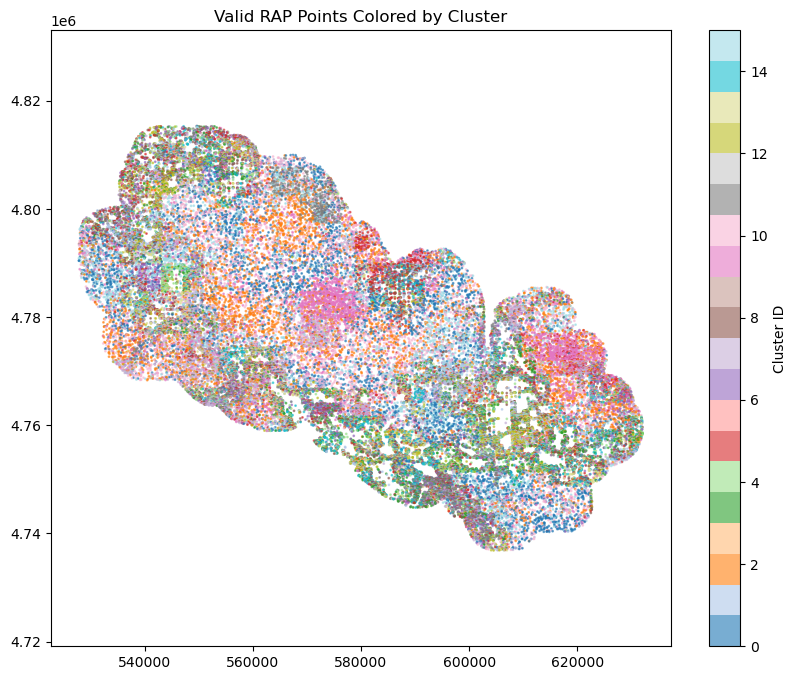

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# LOAD
# -------------------------------------------------------------------
df = pd.read_csv(r"D:\My Drive\rap_energy_joined_for_brms.csv")

# -------------------------------------------------------------------
# SCATTER
# -------------------------------------------------------------------
plt.figure(figsize=(10, 8))

plt.figure(figsize=(10, 8))

sc = plt.scatter(
    df["x_utm11n"],
    df["y_utm11n"],
    c=df["cluster"],
    s=1,
    cmap="tab20",
    alpha=0.6
)

plt.colorbar(sc, label="Cluster ID")
plt.title("Valid RAP Points Colored by Cluster")
plt.axis("equal")

plt.show()

In [38]:
# rough check: local homogeneity
from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = df[["x_utm11n", "y_utm11n"]].values
clusters = df["cluster"].values

nbrs = NearestNeighbors(n_neighbors=5).fit(coords)
_, indices = nbrs.kneighbors(coords)

same_cluster = []
for i, neigh in enumerate(indices):
    same = np.mean(clusters[neigh] == clusters[i])
    same_cluster.append(same)

print("Mean local cluster agreement:", np.mean(same_cluster))

Mean local cluster agreement: 0.357742418782833


In [ ]:
import numpy as np

counts = np.bincount(clusters)
probs = counts / counts.sum()

expected_random = np.sum(probs**2)
print("Expected random agreement:", expected_random)
rand_means = []

for _ in range(50):
    clusters_random = np.random.choice(clusters, size=len(clusters), replace=True)

    same_cluster_rand = []
    for i, neigh in enumerate(indices):
        same = np.mean(clusters_random[neigh] == clusters_random[i])
        same_cluster_rand.append(same)

    rand_means.append(np.mean(same_cluster_rand))

print("Random agreement (bootstrap):", np.mean(rand_means))

import matplotlib.pyplot as plt

plt.bar(range(len(probs)), probs)
plt.title("Cluster proportions")
plt.show()

NameError: name 'clusters' is not defined

In [42]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

coords = df[["x_utm11n", "y_utm11n"]].values
clusters = df["cluster"].values

# ask for 6 neighbors so the first is self, then drop it
nbrs = NearestNeighbors(n_neighbors=6).fit(coords)
_, indices = nbrs.kneighbors(coords)

# remove self neighbor (first column)
indices_no_self = indices[:, 1:]

# observed agreement
same_cluster = []
for i, neigh in enumerate(indices_no_self):
    same = np.mean(clusters[neigh] == clusters[i])
    same_cluster.append(same)

obs = np.mean(same_cluster)
print("Observed agreement (no self):", obs)

# analytical random expectation
counts = np.bincount(clusters)
probs = counts / counts.sum()
expected_random = np.sum(probs**2)
print("Expected random agreement (no self):", expected_random)

# permutation / bootstrap check
np.random.seed(42)
rand_means = []

for _ in range(50):
    clusters_random = np.random.choice(clusters, size=len(clusters), replace=True)

    same_cluster_rand = []
    for i, neigh in enumerate(indices_no_self):
        same = np.mean(clusters_random[neigh] == clusters_random[i])
        same_cluster_rand.append(same)

    rand_means.append(np.mean(same_cluster_rand))

print("Random agreement bootstrap (no self):", np.mean(rand_means))
print("Random agreement bootstrap sd:", np.std(rand_means))
print("Fold increase over random:", obs / expected_random)

Observed agreement (no self): 0.1965445959528912
Expected random agreement (no self): 0.06692754159281347
Random agreement bootstrap (no self): 0.06695048265660263
Random agreement bootstrap sd: 0.0006830819019649709
Fold increase over random: 2.9366773569641427


Below is producing a nearest neighbor classification of the entire pixel data set  -  how does the energy characterization fit with the centroids of k = 16 run 5?

In [ ]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import rasterio


# =============================================================================
# USER SETTINGS
# =============================================================================

# Source raster used to build the 2025 energy features
OUT_RASTER = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)

# Directory containing the original 1M sampled pixel locations
SAMPLE_DIR = Path(r"C:\NCA_DATA\cluster_v2")

# Directory containing selected k=16 run outputs
K16_DIR = Path(r"C:\NCA_DATA\cluster_v4_energy_k16_deepdive")

# Output directory for classified rasters
OUT_DIR = Path(r"C:\NCA_DATA\cluster_v4_energy_k16_assignment_2025")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Output rasters
CLASS_RASTER = OUT_DIR / "energy_k16_class_2025_remaining.tif"
MARGIN_RASTER = OUT_DIR / "energy_k16_margin_2025_remaining.tif"
RATIO_RASTER = OUT_DIR / "energy_k16_d1_over_d2_2025_remaining.tif"
CORE_BOUNDARY_RASTER = OUT_DIR / "energy_k16_core_boundary_2025_remaining.tif"

# Core / boundary threshold on normalized margin = (d2 - d1) / d2
# Lower margin = more boundary-like
# Start with a simple heuristic; can revise later after inspection
BOUNDARY_MARGIN_THRESHOLD = 0.10

# Core/boundary raster encoding
# 0 = nodata / not classified
# 1 = boundary
# 2 = core
BOUNDARY_CODE = 1
CORE_CODE = 2

# Whether to also classify the original 1M sample pixels
# False = classify only remaining pixels
# True  = classify all valid pixels
CLASSIFY_ALL_VALID_PIXELS = False


# =============================================================================
# EXPLICIT BAND MAP
# =============================================================================

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

FEATURE_MAP = {
    "B2":  {"BETA0": 1,  "AMP1": 2,  "AMP2": 4,  "AMP3": 6,  "AMP4": 8},
    "B3":  {"BETA0": 11, "AMP1": 12, "AMP2": 14, "AMP3": 16, "AMP4": 18},
    "B4":  {"BETA0": 21, "AMP1": 22, "AMP2": 24, "AMP3": 26, "AMP4": 28},
    "B5":  {"BETA0": 31, "AMP1": 32, "AMP2": 34, "AMP3": 36, "AMP4": 38},
    "B6":  {"BETA0": 41, "AMP1": 42, "AMP2": 44, "AMP3": 46, "AMP4": 48},
    "B7":  {"BETA0": 51, "AMP1": 52, "AMP2": 54, "AMP3": 56, "AMP4": 58},
    "B8":  {"BETA0": 61, "AMP1": 62, "AMP2": 64, "AMP3": 66, "AMP4": 68},
    "B8A": {"BETA0": 71, "AMP1": 72, "AMP2": 74, "AMP3": 76, "AMP4": 78},
    "B11": {"BETA0": 81, "AMP1": 82, "AMP2": 84, "AMP3": 86, "AMP4": 88},
    "B12": {"BETA0": 91, "AMP1": 92, "AMP2": 94, "AMP3": 96, "AMP4": 98},
}


# =============================================================================
# HELPERS
# =============================================================================

def validate_feature_map(feature_map: dict[str, dict[str, int]]) -> None:
    needed = ["BETA0", "AMP1", "AMP2", "AMP3", "AMP4"]
    missing = {}
    for band in RAW_BANDS:
        if band not in feature_map:
            missing[band] = needed
            continue
        miss = [k for k in needed if k not in feature_map[band]]
        if miss:
            missing[band] = miss
    if missing:
        raise RuntimeError(f"Feature map missing required entries: {missing}")


def get_selected_band_indices(feature_map: dict[str, dict[str, int]]) -> list[int]:
    selected = []
    for band in RAW_BANDS:
        selected.extend([
            feature_map[band]["BETA0"],
            feature_map[band]["AMP1"],
            feature_map[band]["AMP2"],
            feature_map[band]["AMP3"],
            feature_map[band]["AMP4"],
        ])
    return sorted(set(selected))


def build_selected_band_lookup(
    feature_map: dict[str, dict[str, int]],
    selected_indices_1based: list[int]
) -> dict[str, dict[str, int]]:
    pos_map = {idx: pos for pos, idx in enumerate(selected_indices_1based)}
    lookup = {band: {} for band in RAW_BANDS}
    for band in RAW_BANDS:
        for comp, idx in feature_map[band].items():
            lookup[band][comp] = pos_map[idx]
    return lookup


def get_valid_mask(arr, src) -> np.ndarray:
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)
    nodata = src.nodata
    if nodata is not None and np.isfinite(nodata):
        valid &= ~np.any(arr.data == nodata, axis=0)
    return valid


def extract_energy_features_from_block(
    block: np.ndarray,
    lookup: dict[str, dict[str, int]]
) -> np.ndarray:
    energy_cols = []

    for band in RAW_BANDS:
        beta0 = block[lookup[band]["BETA0"]].reshape(-1)
        a1 = block[lookup[band]["AMP1"]].reshape(-1)
        a2 = block[lookup[band]["AMP2"]].reshape(-1)
        a3 = block[lookup[band]["AMP3"]].reshape(-1)
        a4 = block[lookup[band]["AMP4"]].reshape(-1)

        energy = np.sqrt(a1**2 + a2**2 + a3**2 + a4**2)
        energy_cols.extend([beta0, energy])

    return np.column_stack(energy_cols).astype(np.float32)


def load_selected_run(selected_run_txt: Path) -> int:
    txt = selected_run_txt.read_text(encoding="utf-8").strip()
    prefix = "selected_run="
    if not txt.startswith(prefix):
        raise RuntimeError(f"Unexpected selected run file contents: {txt}")
    return int(txt.replace(prefix, "").strip())


def compute_assignment_metrics(Xz: np.ndarray, centers: np.ndarray):
    """
    Compute nearest and second-nearest centroid assignment metrics.

    margin = (d2 - d1) / d2
    ratio  = d1 / d2
    """
    x2 = np.sum(Xz ** 2, axis=1, keepdims=True)     # (n,1)
    c2 = np.sum(centers ** 2, axis=1)[None, :]      # (1,k)
    d2mat = x2 + c2 - 2.0 * (Xz @ centers.T)
    d2mat = np.maximum(d2mat, 0.0)

    order = np.argpartition(d2mat, kth=1, axis=1)[:, :2]
    two = np.take_along_axis(d2mat, order, axis=1)
    sort_idx = np.argsort(two, axis=1)
    order = np.take_along_axis(order, sort_idx, axis=1)
    two = np.take_along_axis(two, sort_idx, axis=1)

    nearest_idx = order[:, 0]
    second_idx = order[:, 1]

    d1 = np.sqrt(two[:, 0]).astype(np.float32)
    d2 = np.sqrt(two[:, 1]).astype(np.float32)

    denom = np.where(d2 <= 1e-12, 1e-12, d2)
    margin = ((d2 - d1) / denom).astype(np.float32)
    ratio = (d1 / denom).astype(np.float32)

    assigned_class = nearest_idx.astype(np.int16)

    return assigned_class, d1, d2, margin, ratio


# =============================================================================
# MAIN
# =============================================================================

def main():
    validate_feature_map(FEATURE_MAP)

    selected_indices_1based = get_selected_band_indices(FEATURE_MAP)
    lookup = build_selected_band_lookup(FEATURE_MAP, selected_indices_1based)

    print("Loading selected run and saved clustering artifacts...")
    selected_run = load_selected_run(K16_DIR / "energy_k16_selected_run.txt")
    print(f"Selected representative run: {selected_run}")

    bundle = np.load(K16_DIR / "energy_k16_bundle.npz")
    centers = bundle[f"centers_run{selected_run}"].astype(np.float32)

    scaler_stats = np.load(K16_DIR / "energy_k16_scaler_stats.npz")
    mean_ = scaler_stats["mean_"].astype(np.float32)
    scale_ = scaler_stats["scale_"].astype(np.float32)

    if centers.shape[1] != len(mean_):
        raise RuntimeError(
            f"Centroid feature count ({centers.shape[1]}) does not match scaler feature count ({len(mean_)})"
        )

    print("Loading sampled pixel coordinates to exclude...")
    rows_1m = np.load(SAMPLE_DIR / "rows_1M.npy").astype(np.int64)
    cols_1m = np.load(SAMPLE_DIR / "cols_1M.npy").astype(np.int64)

    with rasterio.open(OUT_RASTER) as src:
        height, width = src.height, src.width

        sampled_flat = rows_1m * width + cols_1m
        sampled_flat = set(sampled_flat.tolist())

        print("Raster:", OUT_RASTER)
        print("Shape:", (height, width))
        print("Count:", src.count)
        print("Nodata:", src.nodata)
        print(f"Sampled pixels loaded for exclusion: {len(sampled_flat):,}")

        class_profile = src.profile.copy()
        class_profile.update(
            count=1,
            dtype="int16",
            nodata=0,
            compress="deflate"
        )

        float_profile = src.profile.copy()
        float_profile.update(
            count=1,
            dtype="float32",
            nodata=np.float32(-9999.0),
            compress="deflate"
        )

        cb_profile = src.profile.copy()
        cb_profile.update(
            count=1,
            dtype="uint8",
            nodata=0,
            compress="deflate"
        )

        n_blocks = 0
        n_valid_total = 0
        n_assigned_total = 0
        n_skipped_sampled = 0

        with rasterio.open(CLASS_RASTER, "w", **class_profile) as dst_class, \
             rasterio.open(MARGIN_RASTER, "w", **float_profile) as dst_margin, \
             rasterio.open(RATIO_RASTER, "w", **float_profile) as dst_ratio, \
             rasterio.open(CORE_BOUNDARY_RASTER, "w", **cb_profile) as dst_cb:

            for _, window in src.block_windows(1):
                n_blocks += 1

                arr = src.read(indexes=selected_indices_1based, window=window, masked=True)
                valid = get_valid_mask(arr, src)

                block_h = window.height
                block_w = window.width

                class_arr = np.zeros((block_h, block_w), dtype=np.int16)
                margin_arr = np.full((block_h, block_w), -9999.0, dtype=np.float32)
                ratio_arr = np.full((block_h, block_w), -9999.0, dtype=np.float32)
                cb_arr = np.zeros((block_h, block_w), dtype=np.uint8)

                if valid.any():
                    rr, cc = np.where(valid)
                    n_valid = len(rr)
                    n_valid_total += n_valid

                    global_rows = rr.astype(np.int64) + int(window.row_off)
                    global_cols = cc.astype(np.int64) + int(window.col_off)
                    flat_idx = global_rows * width + global_cols

                    if CLASSIFY_ALL_VALID_PIXELS:
                        keep_mask = np.ones(n_valid, dtype=bool)
                    else:
                        keep_mask = np.array([f not in sampled_flat for f in flat_idx], dtype=bool)

                    n_skipped_sampled += int((~keep_mask).sum())

                    if keep_mask.any():
                        block = arr.data.astype(np.float32)
                        X_energy_block = extract_energy_features_from_block(block, lookup)

                        flat_local = rr * block_w + cc
                        X_valid = X_energy_block[flat_local]
                        X_keep = X_valid[keep_mask]

                        # apply saved scaler stats from k=16 workflow
                        Xz = (X_keep - mean_) / scale_

                        assigned_class, d1, d2, margin, ratio = compute_assignment_metrics(Xz, centers)

                        rr_keep = rr[keep_mask]
                        cc_keep = cc[keep_mask]

                        # cluster labels from k-means are 0..15
                        class_arr[rr_keep, cc_keep] = assigned_class + 1

                        margin_arr[rr_keep, cc_keep] = margin
                        ratio_arr[rr_keep, cc_keep] = ratio

                        boundary_mask = margin <= BOUNDARY_MARGIN_THRESHOLD
                        cb_vals = np.where(boundary_mask, BOUNDARY_CODE, CORE_CODE).astype(np.uint8)
                        cb_arr[rr_keep, cc_keep] = cb_vals

                        n_assigned_total += len(rr_keep)

                dst_class.write(class_arr, 1, window=window)
                dst_margin.write(margin_arr, 1, window=window)
                dst_ratio.write(ratio_arr, 1, window=window)
                dst_cb.write(cb_arr, 1, window=window)

                if n_blocks % 50 == 0:
                    print(
                        f"Processed {n_blocks:,} blocks | "
                        f"valid so far: {n_valid_total:,} | "
                        f"assigned so far: {n_assigned_total:,}"
                    )

    print("\nDone.")
    print(f"Blocks processed: {n_blocks:,}")
    print(f"Valid pixels encountered: {n_valid_total:,}")
    print(f"Pixels skipped because they were in the 1M sample: {n_skipped_sampled:,}")
    print(f"Pixels assigned in this run: {n_assigned_total:,}")
    print("\nFiles written:")
    print(CLASS_RASTER)
    print(MARGIN_RASTER)
    print(RATIO_RASTER)
    print(CORE_BOUNDARY_RASTER)


if __name__ == "__main__":
    main()